In [2]:
import scanpy as sc
import anndata
from scipy import io
import scipy
from scipy.sparse import coo_matrix, csr_matrix
import numpy as np
import os
import pickle
import pandas as pd
import matplotlib.pyplot as pl
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42

sc.settings.set_figure_params(facecolor='white', dpi=100, frameon=False)

## From Seurat

In [8]:
# load matrix
X = io.mmread("all_blg_cells_counts.mtx")

# create anndata object
adata = anndata.AnnData(
    X=X.transpose().tocsr()
)

# load metadata
cell_meta = pd.read_csv("all_blg_cells_metadata.csv", low_memory=False)

# load gene names
with open("all_blg_cells_genes.csv", 'r') as f:
    gene_names = f.read().splitlines()

# set anndata observations and index obs by barcodes, var by gene names
adata.obs = cell_meta
adata.obs.index = adata.obs['barcode']
adata.var.index = gene_names

# load PCA dimensional reduction
pca = pd.read_csv("all_blg_cells_pca.csv")
pca.index = adata.obs.index

# set pca and umap for the anndata object
adata.obsm['X_pca'] = pca.to_numpy()
adata.obsm['X_umap'] = np.vstack((adata.obs['UMAP_1'].to_numpy(), adata.obs['UMAP_2'].to_numpy())).T

adata.obs.index.name = "cells"

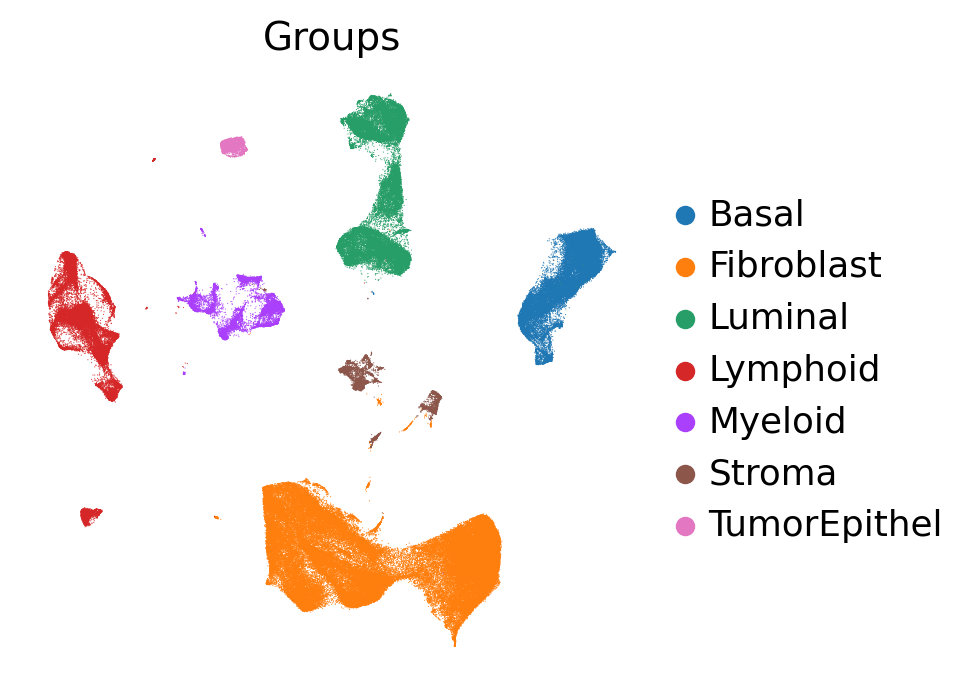

In [7]:
sc.pl.umap(adata, color=['Groups'])

In [9]:
adata.write('all_cells_orig_UMAP.h5ad')

In [11]:
adata = adata[~adata.obs['Group'].isin(["Gestation"])]

In [12]:
#import libraries
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import scanpy as sc
import anndata as ad
import os
import sys
sys.path.append('/data/homezvol3/tzhuravl/bin/bigsur/BigSur')
from BigSur.feature_selection import mcfano_feature_selection as mcfano

sc.pp.filter_genes(adata, min_cells=1)
adata.layers["counts"] = adata.X.copy()
mcfano(adata, layer='counts')

/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:275: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


Using 0.01 for pvalue cutoff and 0.95 for mcfano quantile cutoff for highly variable genes.


In [13]:
adata.var["mt"] = adata.var_names.str.startswith("mt-")
adata.var["ribo"] = adata.var_names.str.startswith(("Rps", "Rpl"))

sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo"], inplace=True, log1p=True
)

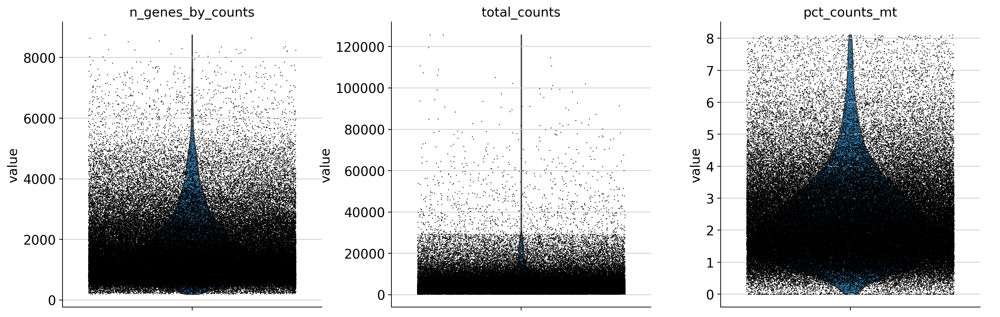

In [14]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

In [15]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

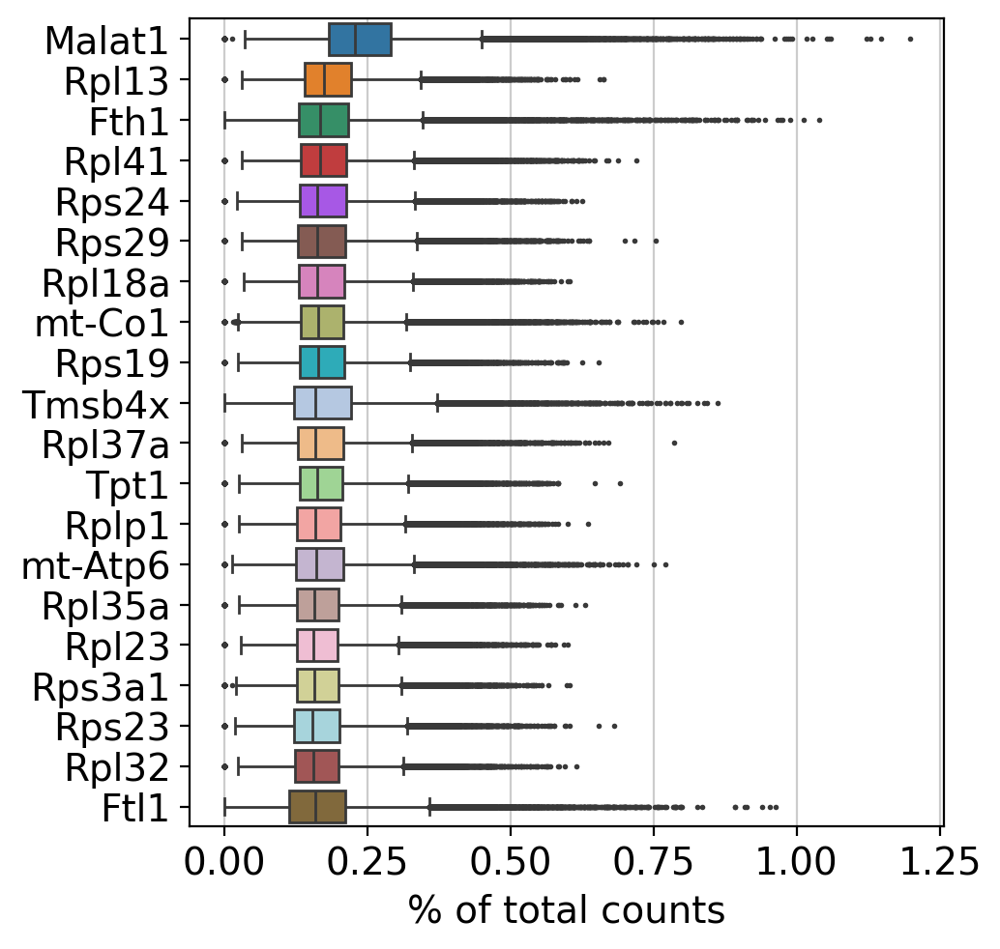

In [16]:
sc.pl.highest_expr_genes(adata, n_top=20)

In [17]:
adata.raw = adata

In [18]:
adata = adata[:, adata.var.highly_variable].copy()
sc.pp.regress_out(adata, ['total_counts'])
sc.pp.scale(adata, max_value=10)

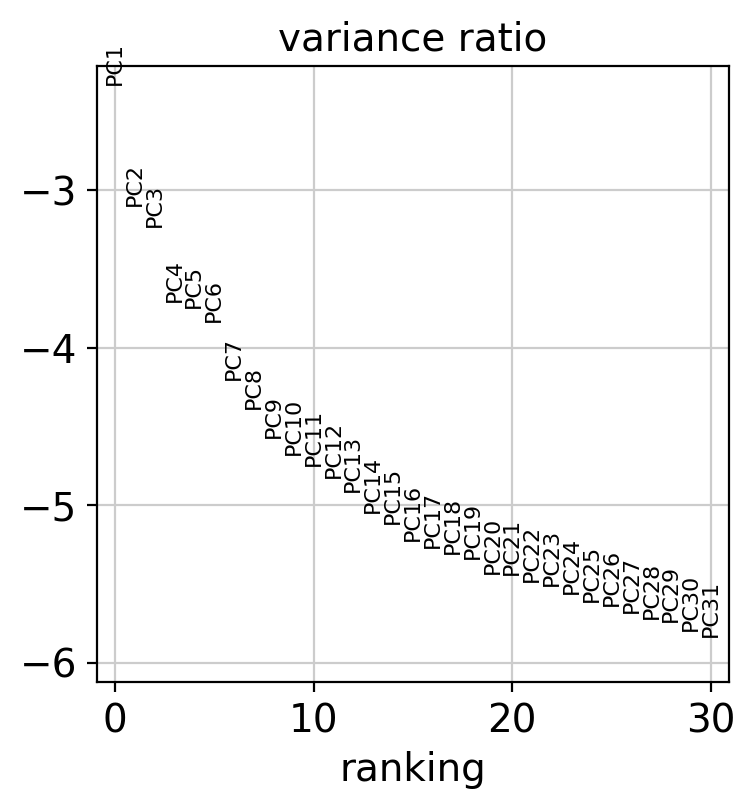

In [19]:
sc.tl.pca(adata, svd_solver="arpack")
sc.pl.pca_variance_ratio(adata, log=True)

In [20]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

In [21]:
sc.tl.leiden(
    adata,
    resolution=0.1,
    random_state=0,
    n_iterations=2,
    directed=False,
)

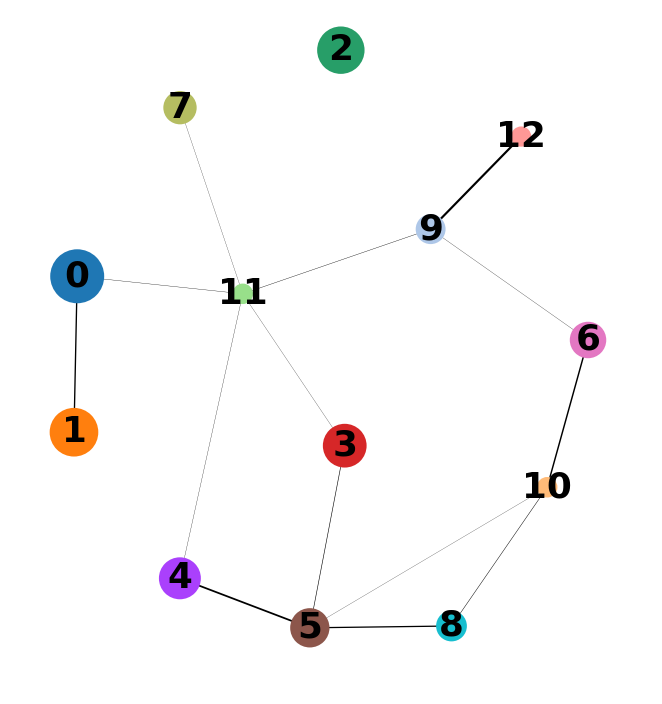

In [22]:
sc.tl.paga(adata)
sc.pl.paga(adata)
sc.tl.umap(adata, init_pos='paga')

In [23]:
adata

AnnData object with n_obs × n_vars = 128807 × 1050
    obs: 'orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'Sample', 'barcode', 'SeqID', 'SampleID', 'Age', 'Condition', 'Batch', 'UmiSums', 'GenesDetected', 'prcntMito', 'residDetectionTrend', 'DbltScore', 'Experiment', 'UMAP1', 'UMAP2', 'Cluster', 'Group', 'MajorGroups', 'Groups', 'CellTypes', 'CellTypesFinal', 'Colors', 'ptime', 'ptimeBin', 'GroupColors', 'UMAP_1', 'UMAP_2', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'leiden'
    var: 'n_cells', 'mc_Fano', 'FDR_adj_pvalue', 'p_value', 'highly_variable', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts',

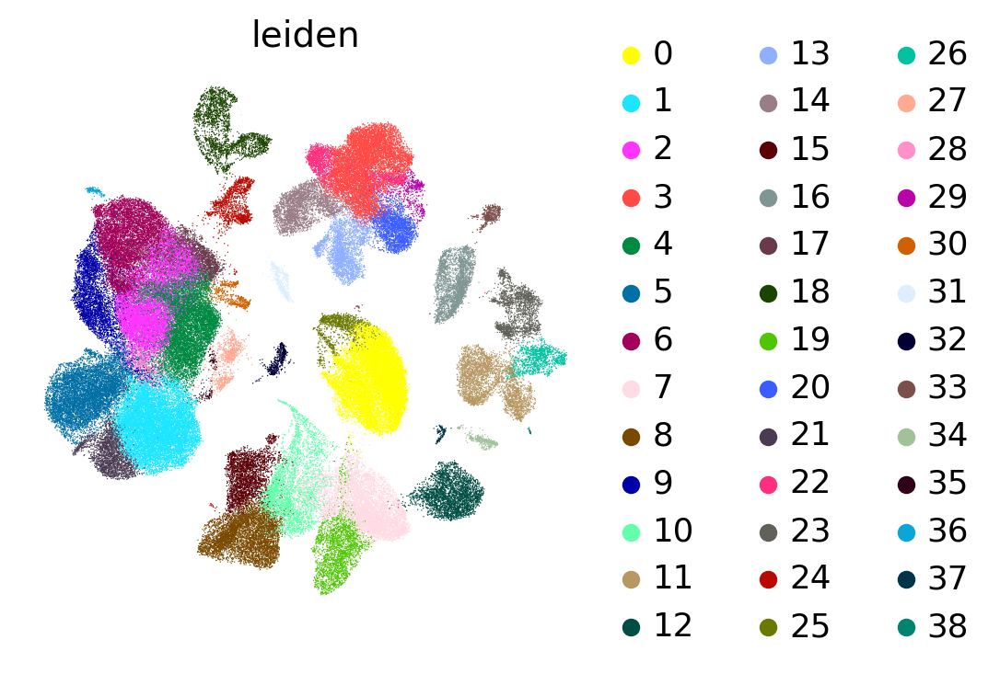

In [34]:
sc.tl.leiden(
    adata,
    resolution=1,
    random_state=0,
    n_iterations=2,
    directed=False,
)

sc.pl.umap(
    adata,
    color=["leiden"])

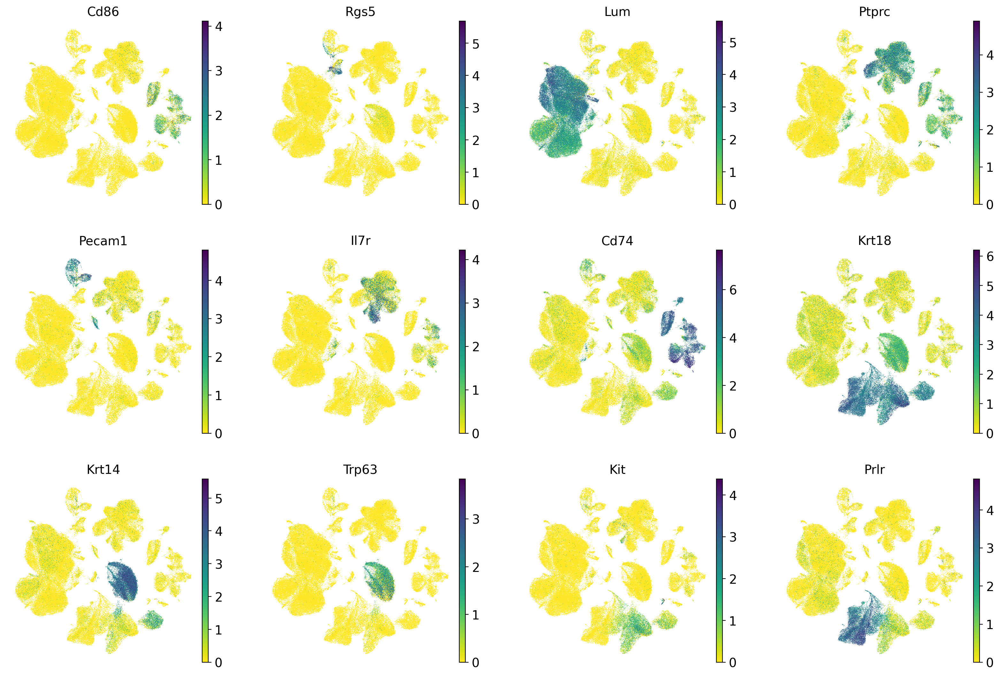

In [25]:
sc.pl.umap(adata, color=["Cd86", "Rgs5", "Lum", "Ptprc", "Pecam1","Il7r", 
                        "Cd74","Krt18", "Krt14", "Trp63", "Kit", "Prlr"],cmap='viridis_r')

In [7]:
barcode = pd.read_csv("all_cells_barcodes_dict.csv", index_col=0)

In [113]:
adata.obs['barcode'] = barcode['barcode']

In [115]:
adata.obs.index = adata.obs['barcode']

In [116]:
adata.obs

,orig.ident,nCount_originalexp,nFeature_originalexp,Sample,barcode,SeqID,SampleID,Age,Condition,Batch,...,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,leiden,cell_type
barcode,,,,,,,,,,,,,,,,,,,,,
TCGGGACTCACCGGGT-H2,cell,2770.0,1096,SampleH2,TCGGGACTCACCGGGT-H2,H2,CBLA13,74.0,WTOld,2,...,63.068592,78.483755,95,4.564348,3.429603,658,6.490724,23.754513,6,Fibroblasts
TGTATTCCAGGTGCCT-A11,cell,3820.0,1566,SampleA11,TGTATTCCAGGTGCCT-A11,A11,WKBR61.4dTM,46.0,5,1,...,54.057592,71.963351,130,4.875197,3.403141,469,6.152733,12.277487,12,Cancer_epithelial
GAGACTTGTACGGATG-E8,cell,1382.0,699,SampleE8,GAGACTTGTACGGATG-E8,E8,WKBR90.3i,33.0,1,3,...,63.892909,85.600579,25,3.258097,1.808973,298,5.700444,21.562952,4,Fibroblasts
TTCGAAGAGCGTGAAC-A2,cell,1184.0,706,SampleA2,TTCGAAGAGCGTGAAC-A2,A2,WKBR75.4bMG,48.0,3,2,...,57.263514,82.601351,16,2.833213,1.351351,344,5.843544,29.054054,6,Fibroblasts
TTAGGCAGTCGATTGT-C12,cell,13268.0,3150,SampleC12,TTAGGCAGTCGATTGT-C12,C12,WKBR65.2g,41.0,2,1,...,62.134459,73.010250,358,5.883322,2.698221,5266,8.569216,39.689478,7,Luminal_Sec
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CGGGTGTAGGAATGTT-E8,cell,828.0,472,SampleE8,CGGGTGTAGGAATGTT-E8,E8,WKBR90.3i,33.0,1,3,...,67.149758,100.000000,23,3.178054,2.777778,274,5.616771,33.091787,16,Bcells
TACACGAAGGGCTCTC-B12,cell,8804.0,2489,SampleB12,TACACGAAGGGCTCTC-B12,B12,WKBR65.2f,41.0,2,1,...,58.223535,71.501590,364,5.899897,4.134484,2823,7.945910,32.064970,15,Luminal_HS
CCACGTTTCCTTACCG-A8,cell,4798.0,1799,SampleA8,CCACGTTTCCTTACCG-A8,A8,WKBR91.1e,41.0,1,3,...,52.667778,69.383076,54,4.007333,1.125469,1047,6.954639,21.821592,21,Fibroblasts


In [8]:
adata.write('all_cells_bigsur_merged.h5ad')

In [3]:
adata = sc.read_h5ad('all_cells_bigsur_merged.h5ad')

In [4]:
adata.obs.columns

Index(['orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'Sample',
       'barcode', 'SeqID', 'SampleID', 'Age', 'Condition', 'Batch', 'UmiSums',
       'GenesDetected', 'prcntMito', 'residDetectionTrend', 'DbltScore',
       'Experiment', 'UMAP1', 'UMAP2', 'Cluster', 'Group', 'MajorGroups',
       'Groups', 'CellTypes', 'CellTypesFinal', 'Colors', 'ptime', 'ptimeBin',
       'GroupColors', 'UMAP_1', 'UMAP_2', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes',
       'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes',
       'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt',
       'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo',
       'leiden', 'cell_type', 'subtype', 'p.value', 'correlation', 'cnv'],
      dtype='object')

In [5]:
adata

AnnData object with n_obs × n_vars = 128807 × 1050
    obs: 'orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'Sample', 'barcode', 'SeqID', 'SampleID', 'Age', 'Condition', 'Batch', 'UmiSums', 'GenesDetected', 'prcntMito', 'residDetectionTrend', 'DbltScore', 'Experiment', 'UMAP1', 'UMAP2', 'Cluster', 'Group', 'MajorGroups', 'Groups', 'CellTypes', 'CellTypesFinal', 'Colors', 'ptime', 'ptimeBin', 'GroupColors', 'UMAP_1', 'UMAP_2', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'leiden', 'cell_type', 'subtype', 'p.value', 'correlation', 'cnv'
    var: 'n_cells', 'mc_Fano', 'FDR_adj_pvalue', 'p_value', 'highly_variable', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_

/home/jovyan/.local/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


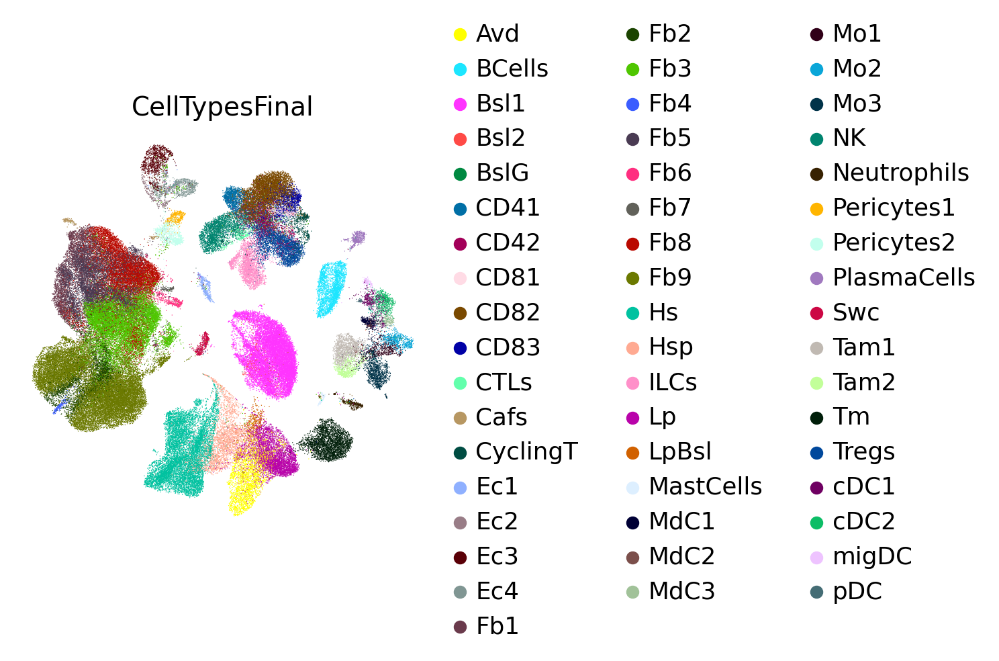

In [3]:
sc.pl.umap(adata, color=['CellTypesFinal'])

In [ ]:
sc.tl.rank_genes_groups(adata, groupby="CellTypesFinal", method="wilcoxon")
sc.tl.dendrogram(adata, groupby = "CellTypesFinal")
sc.pl.rank_genes_groups_dotplot(
    adata, groupby="CellTypesFinal", standard_scale="var", n_genes=3
)

In [19]:
mystery = sc.get.rank_genes_groups_df(adata, 'Cafs')

In [20]:
mystery = mystery[mystery['pvals_adj'] < 0.05]
mystery = mystery[mystery['logfoldchanges'] > 1.5]
mystery.to_csv("Cafs_degs.csv")

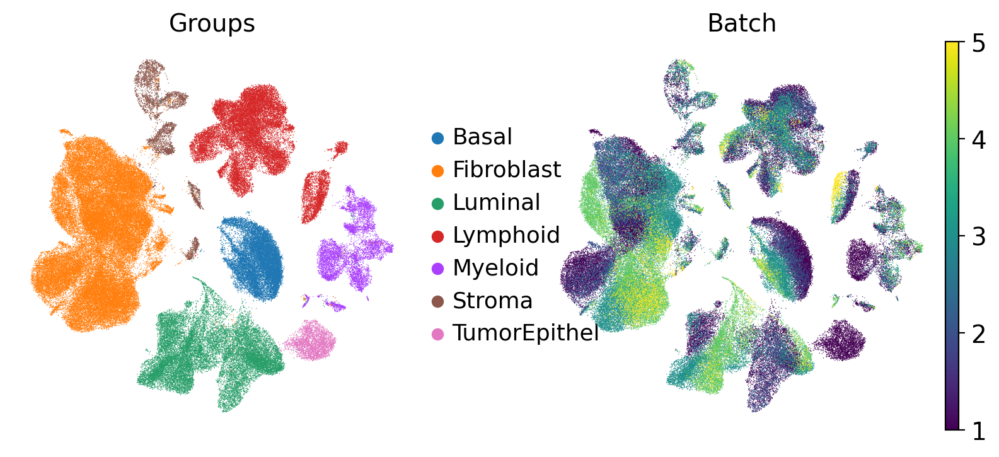

In [41]:
sc.pl.umap(adata, color=['Groups','Batch'])

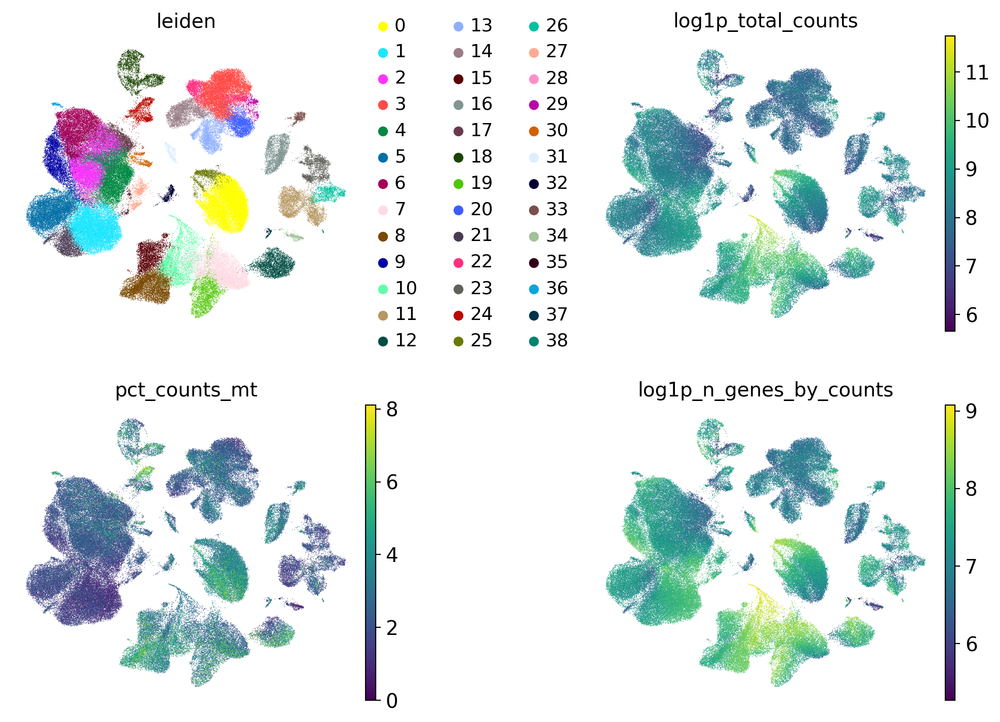

In [35]:
sc.pl.umap(
    adata,
    color=["leiden", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.5,
    ncols=2,
)

In [70]:
marker_genes = {
    "Proliferating": ["Top2a", "Mki67"],
    "Tumor": ["S100a14", "Cdkn2a"],
    "Basal": ["Krt5", "Krt14", "Trp63", "Tagln", "Acta2", "Mylk"],
    "Fibroblasts": ["Lum", "Dcn"],
    "Myeloid": ["Cd74"],
    "Tcells": ["Il7r","Cd3e"],
    "Bcells": ["Cd79a","Bank1"],
    "Neutrophils": ["Ptprc","Ly6g","Retnlg","Cxcr2","Mmp8"],
    "LumSec": ["Kit", "Krt8", "Krt18","Elf5"],
    "LumHR": ["Prlr", "Areg", "Esr1", "Pgr", "Erbb2", "Krt19"],
    "Pericytes": ["Rgs5"],
    "VSMC": ["Synm","Rergl","Pln"],
    "Perifibro": ["Sept4", "Col12a1", "Col8a1", "F2r"],
    "Adipo": ["Tenm2","Fat3","Apod","Idi1","Msmo1","Ifi30","Cyp51"],
    "Schwann": ["Ecm1","Smoc2","Plp1","Mbp","Sox10","Ngfr"],
    "Endothelial": ["Pecam1"]
}

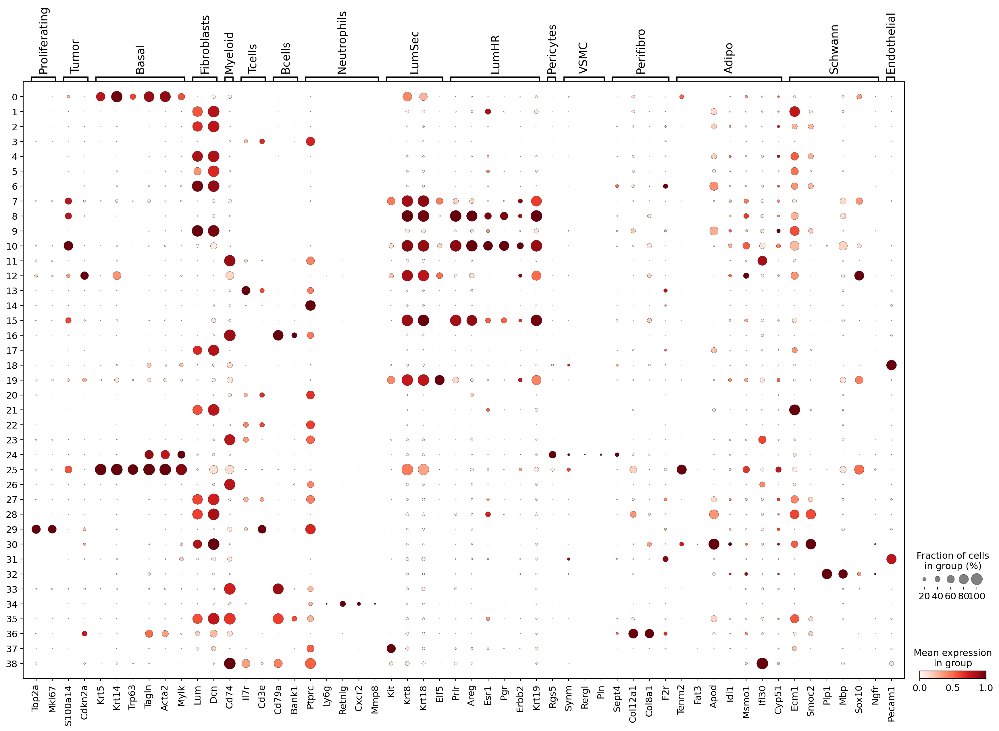

In [71]:
sc.pl.dotplot(adata, marker_genes, groupby="leiden", standard_scale="var")

In [8]:
adata.obs["cell_type"] = adata.obs["leiden"].map(
    {
        "0": "Bmyo",
        "1": "fibroblasts",
        "2": "fibroblasts",
        "3": "Tcells",
        "4": "fibroblasts",
        "5": "fibroblasts",
        "6": "fibroblasts",
        "7": "LumSec",
        "8": "LumHS",
        "9": "fibroblasts",
        "10": "LumHS",
        "11": "myeloid",
        "12": "tumor",
        "13": "Tcells",
        "14": "Tcells",
        "15": "LumHS",
        "16": "Bcells",
        "17": "fibroblasts",
        "18": "endothelial",
        "19": "LumSec",
        "20": "Tcells",
        "21": "fibroblasts",
        "22": "Tcells",
        "23": "myeloid",
        "24": "pericytes",
        "25": "Bmyo",
        "26": "myeloid",
        "27": "doublets",
        "28": "fibroblasts",
        "29": "Tcells",
        "30": "fibroblasts",
        "31": "endothelial",
        "32": "schwann",
        "33": "Bcells",
        "34": "neutrophils",
        "35": "doublets",
        "36": "fibroblasts",
        "37": "doublets",
        "38": "Tcells"
    }
)

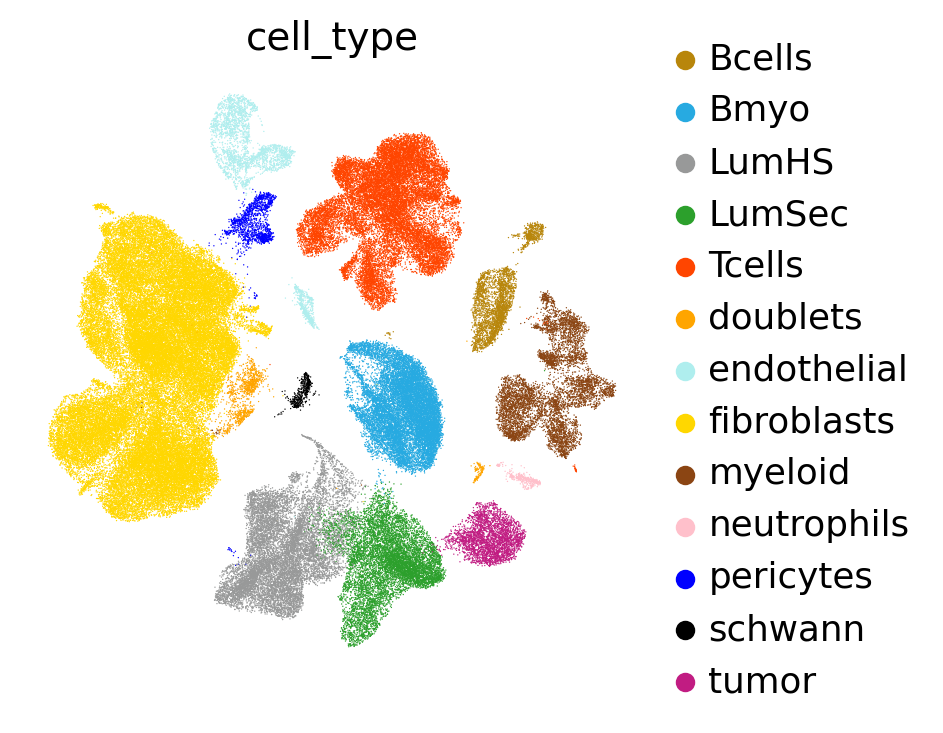

In [5]:
sc.pl.umap(adata, color=["cell_type"])

In [ ]:
marker_genes = {
    "Bmyo": ["Krt14"],
    "LumSec": ["Wfdc18"],
    "tumor": ["Cdkn2a"],
    "LumHS": ["Esr1"],
    "Bcells": ["Igkc"],
    "Tcells": ["Il7r"],
    "myeloid": ["Cd74"],
    "fibroblasts": ["Lum"],
    "pericytes": ["Rgs5"],
    "endothelial": ["Pecam1"],
    "schwann": ["Plp1"]
}

sc.pl.dotplot(adata, marker_genes, groupby="cell_type", standard_scale="var",
             categories_order = ["Bmyo",
    "LumSec",
    "tumor",
    "LumHS",
    "Bcells",
    "Tcells",
    "myeloid",
    "fibroblasts",
    "pericytes",
    "endothelial",
                                "schwann"],
             cmap="Grays",
             save='allcells.pdf')

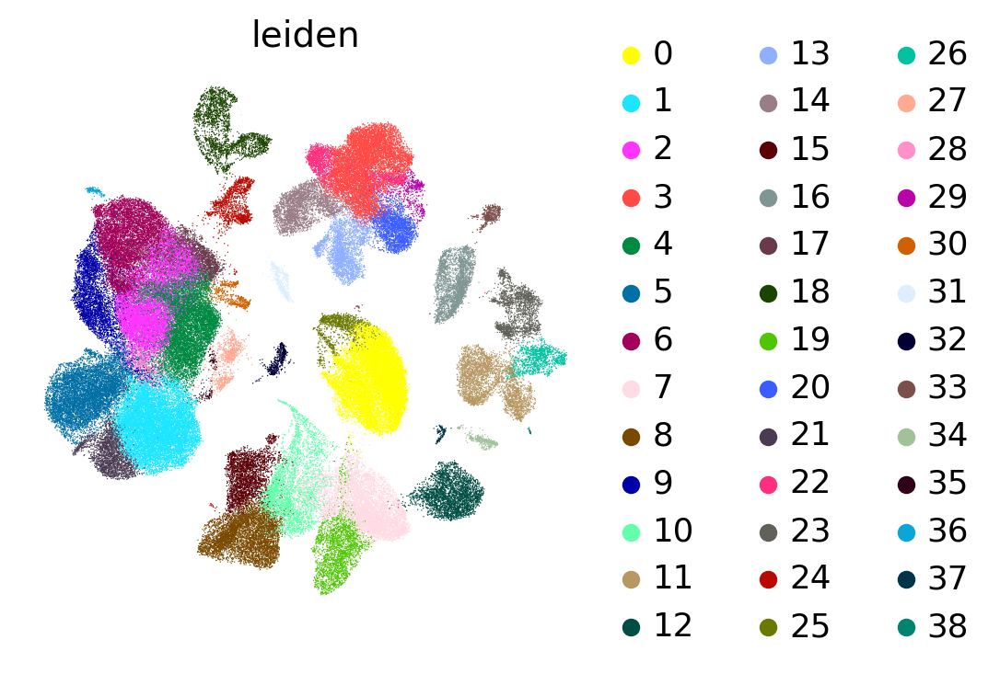

In [44]:
sc.pl.umap(adata, color=["leiden"])

/home/jovyan/.local/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


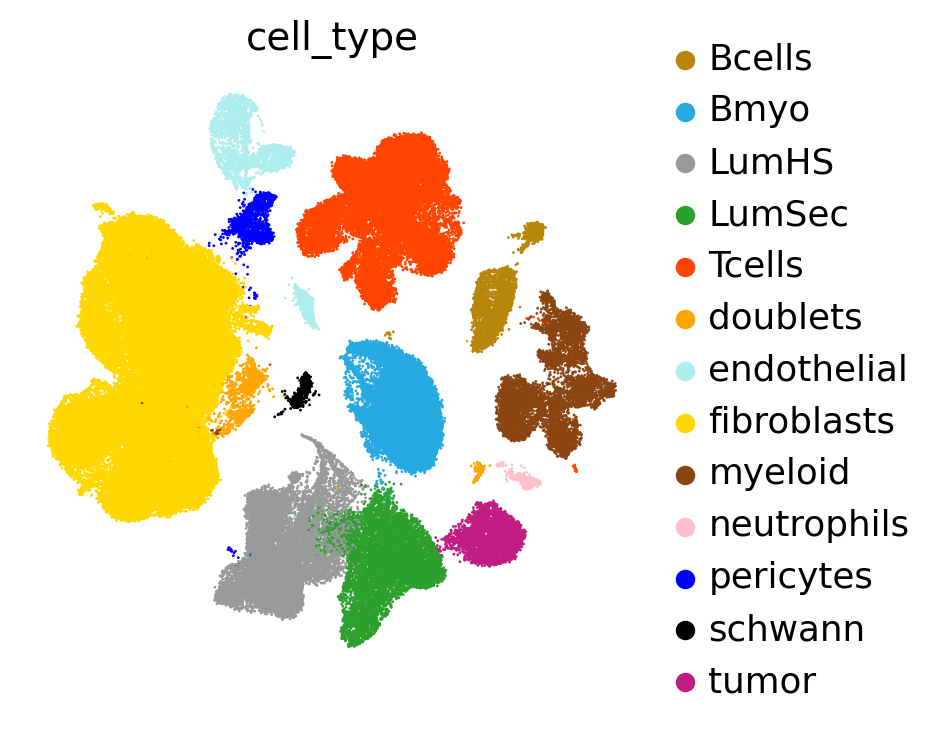

In [17]:
sc.pl.umap(adata, color='cell_type',palette = {'Bmyo':'#27AAE1',
              'tumor':'#C11C82',
              'fibroblasts':'gold',
              'myeloid':'saddlebrown',
              'LumHS':'#989999',
              'LumSec':'#2ca02c',
              'pericytes':'blue',
              'neutrophils':'pink',
              'Tcells':'orangered',
              'endothelial':'paleturquoise',
              'Bcells':'darkgoldenrod',
            'schwann':'black',
            'doublets':'orange'},s=4,
           save='_cell_type_final.pdf')

/home/jovyan/.local/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


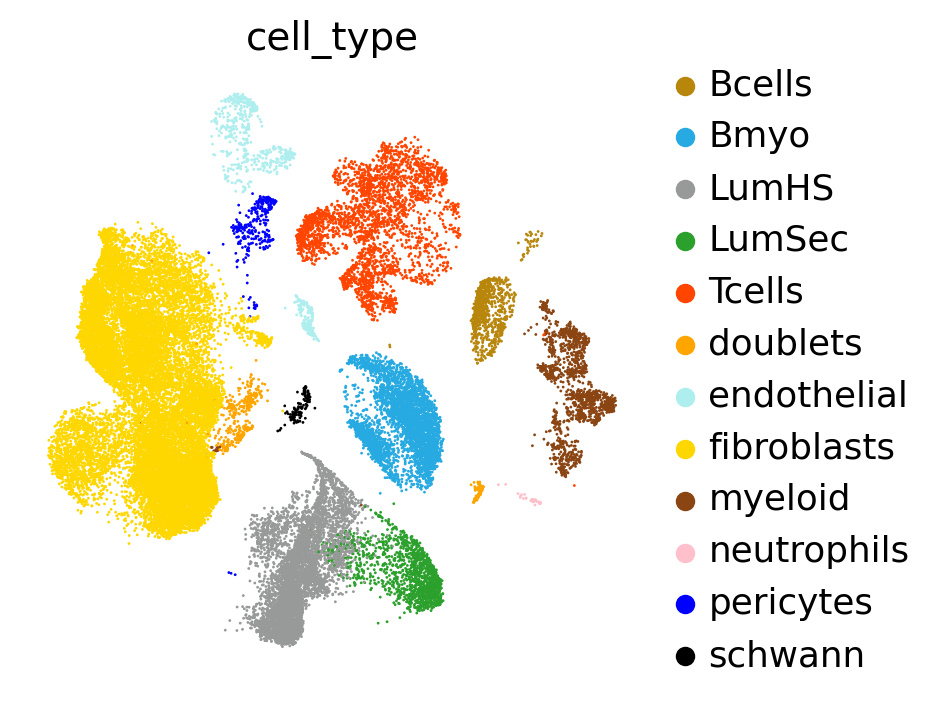

In [18]:
tum = adata[adata.obs['Group'].isin(["Control"])]
tum

sc.pl.umap(
    tum,color=["cell_type"],s=4,
    wspace=0.5, sort_order=None,
)

/home/jovyan/.local/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


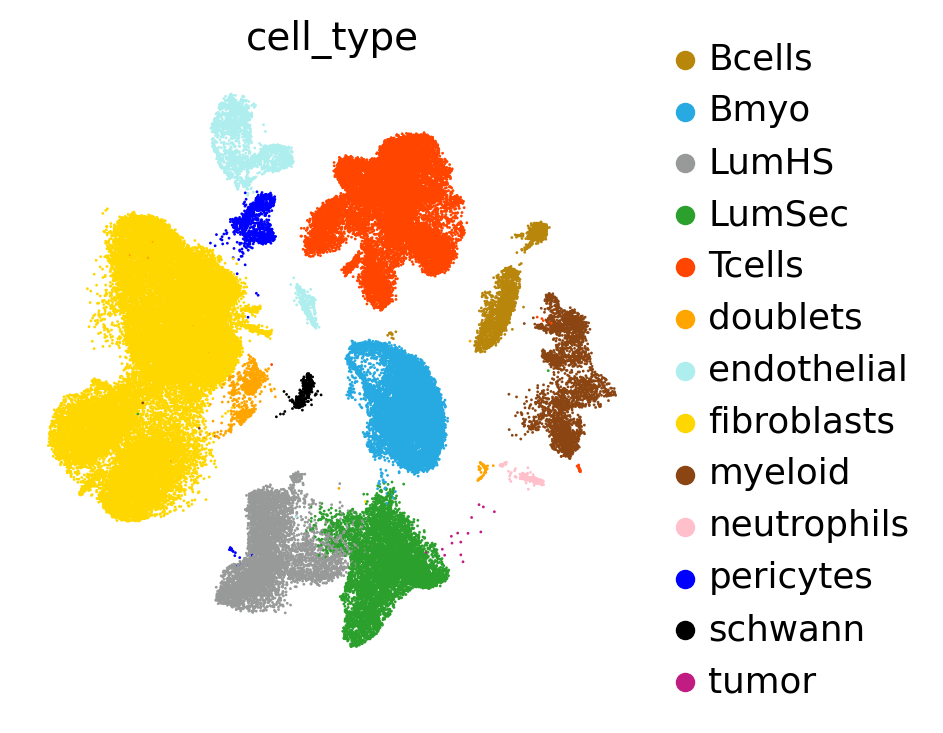

In [19]:
tum = adata[adata.obs['Group'].isin(["WKBR_MG"])]
tum

sc.pl.umap(
    tum,color=["cell_type"],s=4,
    wspace=0.5, sort_order=None,
)

/home/jovyan/.local/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


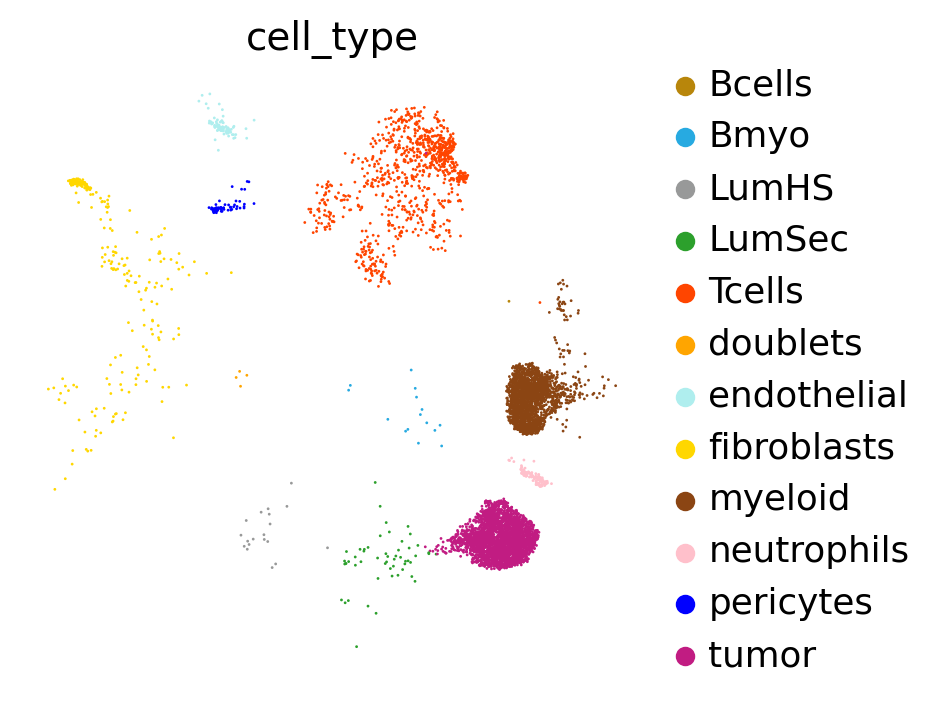

In [20]:
tum = adata[adata.obs['Group'].isin(["WKBR_Tumor"])]
tum

sc.pl.umap(
    tum,color=["cell_type"],s=4,
    wspace=0.5, sort_order=None,
)

In [21]:
adata.obs['Group'].value_counts()

WKBR_MG       83581
Control       38487
WKBR_Tumor     6739
Name: Group, dtype: int64

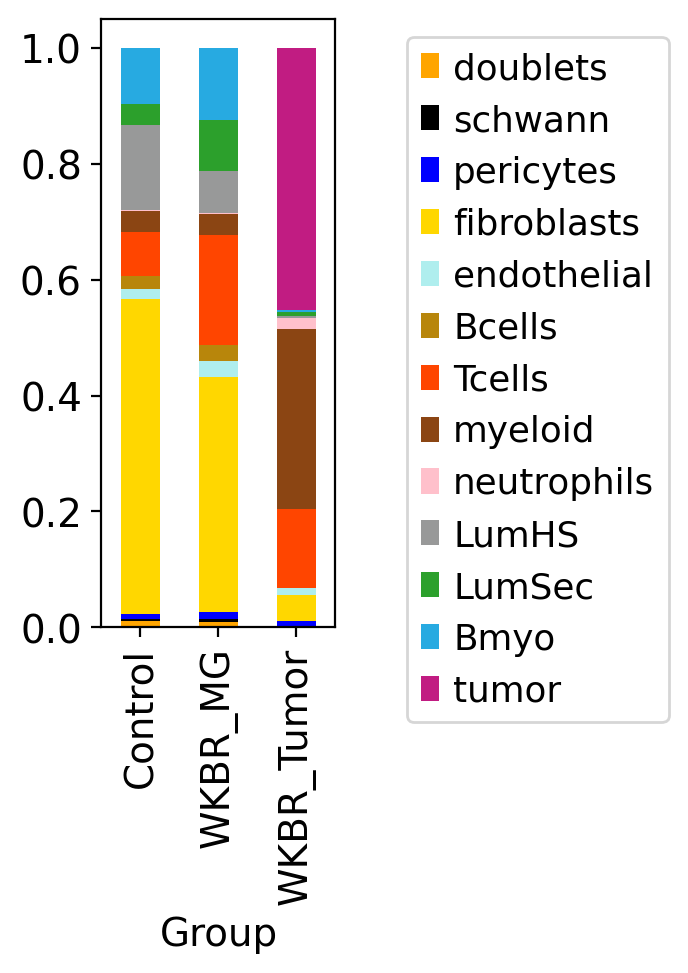

In [58]:
tmp = pd.crosstab(adata.obs['cell_type'],adata.obs['Group'], 
                  normalize='columns').reindex(["doublets",
                                                "schwann",
                                                "pericytes",
                                                "fibroblasts",
                                                "endothelial",
                                                "Bcells",
                                                "Tcells",
                                                "myeloid",
                                                "neutrophils",
                                                "LumHS",
                                                "LumSec",
                                                "Bmyo",
                                                "tumor"])[["Control",
                                         "WKBR_MG",
                                        "WKBR_Tumor"]].T.plot(kind='bar',
                                                              figsize=(1.5, 4),
                                                                                                            stacked=True,color=['orange',
                                                                                                                                'black',
                                                                                                                                'blue',
                                                                                                                                'gold',
                                                                                                                                'paleturquoise',
                                                                                                                                'darkgoldenrod',
                                                                                                                                'orangered',
                                                                                                                                'saddlebrown',
                                                                                                                                'pink',
                                                                                                                                '#989999',
                                                                                                                                '#2ca02c',
                                                                                                                                '#27AAE1',
                                                                                                                                '#C11C82'])
tmp.legend(title='', bbox_to_anchor=(2.5, 1),loc='upper right')
plt.grid(None)
pl.savefig('cell_type_vs_condition_stackedbar_plot.pdf', bbox_inches='tight')

In [4]:
pred = pd.read_csv("ctrl2ctrl3_asnorm_from_all_copykat_prediction.txt",sep='\t')

In [5]:
pred.set_index("cell.names", inplace=True)

In [6]:
adata.obs['ploidy'] = pred['copykat.pred']

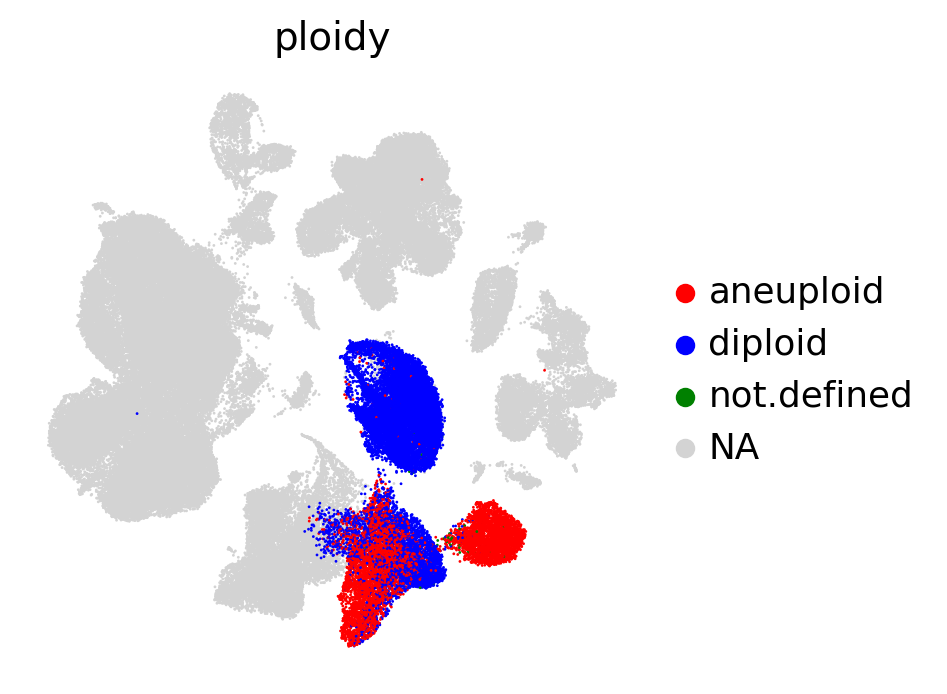

In [7]:
sc.pl.umap(adata, color='ploidy',s=4,palette=["red","blue","green"],
           save='_cnv.pdf')

In [43]:
adata.obs['SampleID'].value_counts()

CTRL_1         10264
WKBR90.3i      10207
CTRL_2          9594
WKBR65.2f       8673
WKBR91.3j       7974
WKBR65.3i       7705
WKBR91.1f       7502
CBLT            7458
WKBR65.2g       7337
CBLA13          6435
WKBR61.4dTM     6022
WKBR65.3g       5893
WKBR65.3h       5548
WKBR90.3g       5178
WKBR76.4f       5007
CTRL_3          4736
WKBR75.4bMG     4497
WKBR61.4dMG     4484
WKBR91.1e       3576
WKBR75.4bTM      717
Name: SampleID, dtype: int64

In [42]:
epi = adata[adata.obs['cell_type'].isin(['Bmyo',
                                           'LumSec',
                                           'tumor'])]

In [44]:
wt = epi[epi.obs['Group'].isin(['Control'])]
df=wt.obs.copy()
df['Match_aneu'] = (df['cnv'] == "aneuploid").astype(int)
category_match = df.groupby('cell_type')['Match_aneu'].mean() * 100
rep_match = df.groupby(['cell_type','SampleID'])['Match_aneu'].mean() * 100
rep_match=pd.DataFrame(rep_match)
print(category_match)

cell_type
Bmyo      0.000000
LumSec    1.250869
Name: Match_aneu, dtype: float64


/tmp/ipykernel_735498/674663140.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cell_type', y='Match_aneu', data=rep_match, palette=colors)#, order=category_order)


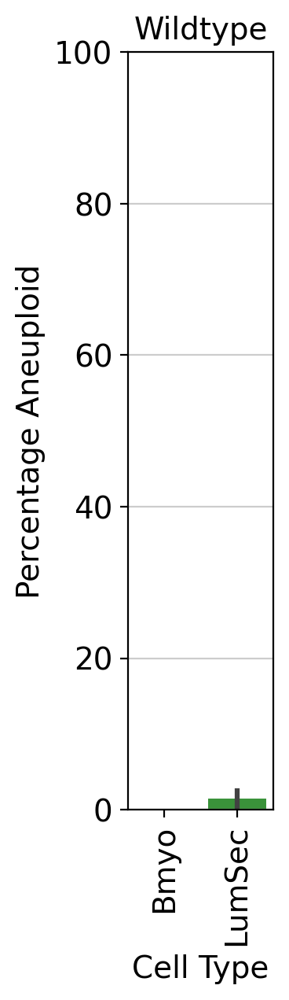

In [48]:
colors=['#27AAE1','#2ca02c']

plt.figure(figsize=(2, 6))
sns.barplot(x='cell_type', y='Match_aneu', data=rep_match, palette=colors)#, order=category_order)
plt.xlabel('Cell Type')
plt.ylabel('Percentage Aneuploid')
plt.title('Wildtype')
plt.tight_layout()
plt.xticks(rotation=90, ha='center')
plt.ylim(0, 100)
plt.savefig('percent_aneuploid_WT.pdf', format='pdf')
plt.show()

In [50]:
wt = epi[epi.obs['Group'].isin(['WKBR_MG'])]
df=wt.obs.copy()
df['Match_aneu'] = (df['cnv'] == "aneuploid").astype(int)
category_match = df.groupby('cell_type')['Match_aneu'].mean() * 100
rep_match = df.groupby(['cell_type','SampleID'])['Match_aneu'].mean() * 100
rep_match=pd.DataFrame(rep_match)
print(category_match)

cell_type
Bmyo       0.251548
LumSec    37.074692
tumor     81.250000
Name: Match_aneu, dtype: float64


/tmp/ipykernel_735498/3065287120.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cell_type', y='Match_aneu', data=rep_match, palette=colors)#, order=category_order)


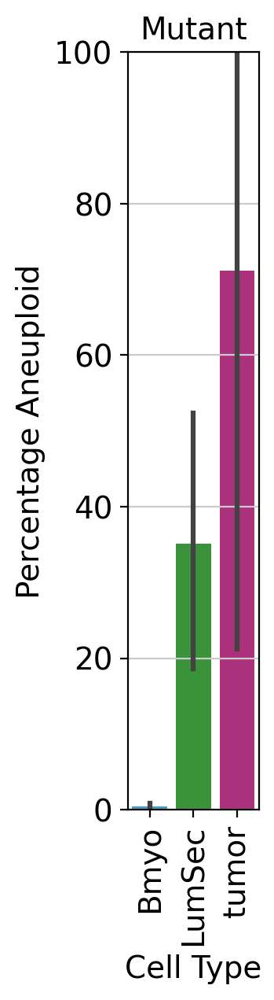

In [51]:
colors=['#27AAE1','#2ca02c','#C11C82']

plt.figure(figsize=(2, 6))
sns.barplot(x='cell_type', y='Match_aneu', data=rep_match, palette=colors)#, order=category_order)
plt.xlabel('Cell Type')
plt.ylabel('Percentage Aneuploid')
plt.title('Mutant')
plt.tight_layout()
plt.xticks(rotation=90, ha='center')
plt.ylim(0, 100)
plt.savefig('percent_aneuploid_MUT.pdf', format='pdf')
plt.show()

In [54]:
wt = epi[epi.obs['Group'].isin(["WKBR_Tumor"])]
df=wt.obs.copy()
df['Match_aneu'] = (df['cnv'] == "aneuploid").astype(int)
category_match = df.groupby('cell_type')['Match_aneu'].mean() * 100
rep_match = df.groupby(['cell_type','SampleID'])['Match_aneu'].mean() * 100
rep_match=pd.DataFrame(rep_match)
print(category_match)

cell_type
Bmyo       0.000000
LumSec    53.703704
tumor     87.155963
Name: Match_aneu, dtype: float64


/tmp/ipykernel_735498/3886474000.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cell_type', y='Match_aneu', data=rep_match, palette=colors)#, order=category_order)


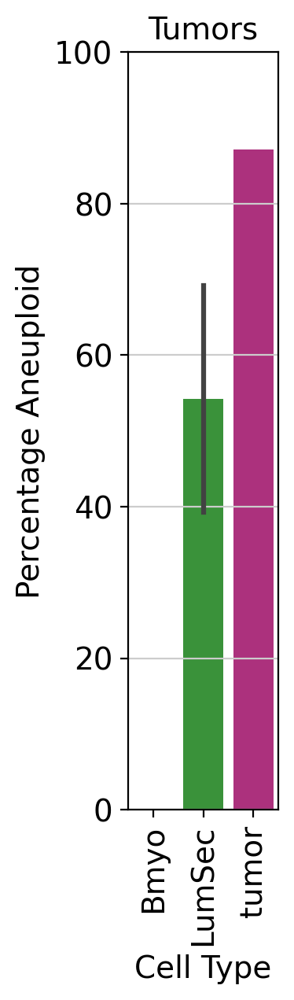

In [56]:
colors=['#27AAE1','#2ca02c','#C11C82']

plt.figure(figsize=(2, 6))
sns.barplot(x='cell_type', y='Match_aneu', data=rep_match, palette=colors)#, order=category_order)
plt.xlabel('Cell Type')
plt.ylabel('Percentage Aneuploid')
plt.title('Tumors')
plt.tight_layout()
plt.xticks(rotation=90, ha='center')
plt.ylim(0, 100)
plt.savefig('percent_aneuploid_TUM.pdf', format='pdf')
plt.show()

In [104]:
pd.crosstab(adata.obs['Groups'],adata.obs['cell_type'], 
                  normalize='columns')

cell_type,Basal_myoepithelial,Bcells,Cancer_epithelial,Cancer_fibroblasts,Endothelial,Fibro_immune_doublet,Fibroblasts,Luminal_HS,Luminal_Sec,Myeloid,Neutrophils,Pericytes,Schwann,Tcells
Groups,,,,,,,,,,,,,,
Basal,0.996226,0.003474,0.000000,0.001383,0.003017,0.000833,0.000055,0.000000,0.002255,0.000000,0.010929,0.001403,0.014085,0.000000
Fibroblast,0.000214,0.000000,0.000000,0.998617,0.039557,0.902500,0.998899,0.000937,0.002706,0.006236,0.038251,0.093969,0.054326,0.001412
Luminal,0.003561,0.002211,0.003585,0.000000,0.007375,0.006667,0.000000,0.998210,0.991094,0.004210,0.016393,0.017532,0.010060,0.000857
Lymphoid,0.000000,0.991156,0.000652,0.000000,0.000670,0.001667,0.000000,0.000341,0.000789,0.001403,0.013661,0.002104,0.016097,0.995866
Myeloid,0.000000,0.002843,0.000326,0.000000,0.000000,0.087500,0.000018,0.000085,0.000000,0.985033,0.918033,0.000000,0.006036,0.001714
Stroma,0.000000,0.000316,0.000326,0.000000,0.949380,0.000833,0.001028,0.000426,0.001015,0.003118,0.002732,0.884993,0.899396,0.000151
TumorEpithel,0.000000,0.000000,0.995111,0.000000,0.000000,0.000000,0.000000,0.000000,0.002142,0.000000,0.000000,0.000000,0.000000,0.000000


In [105]:
pd.crosstab(adata.obs['cell_type'],adata.obs['Groups'], 
                  normalize='columns')

Groups,Basal,Fibroblast,Luminal,Lymphoid,Myeloid,Stroma,TumorEpithel
cell_type,,,,,,,
Basal_myoepithelial,0.995871,0.000053,0.002418,0.000000,0.000000,0.000000,0.000000
Bcells,0.000783,0.000000,0.000338,0.136827,0.001322,0.000216,0.000000
Cancer_epithelial,0.000000,0.000000,0.000532,0.000087,0.000147,0.000216,0.993815
Cancer_fibroblasts,0.000071,0.012750,0.000000,0.000000,0.000000,0.000000,0.000000
Endothelial,0.000641,0.002084,0.001064,0.000087,0.000000,0.610608,0.000000
Fibro_immune_doublet,0.000071,0.019125,0.000387,0.000087,0.015423,0.000216,0.000000
Fibroblasts,0.000214,0.961078,0.000000,0.000000,0.000147,0.012074,0.000000
Luminal_HS,0.000000,0.000194,0.566338,0.000174,0.000147,0.001078,0.000000
Luminal_Sec,0.001424,0.000424,0.425056,0.000305,0.000000,0.001940,0.006185


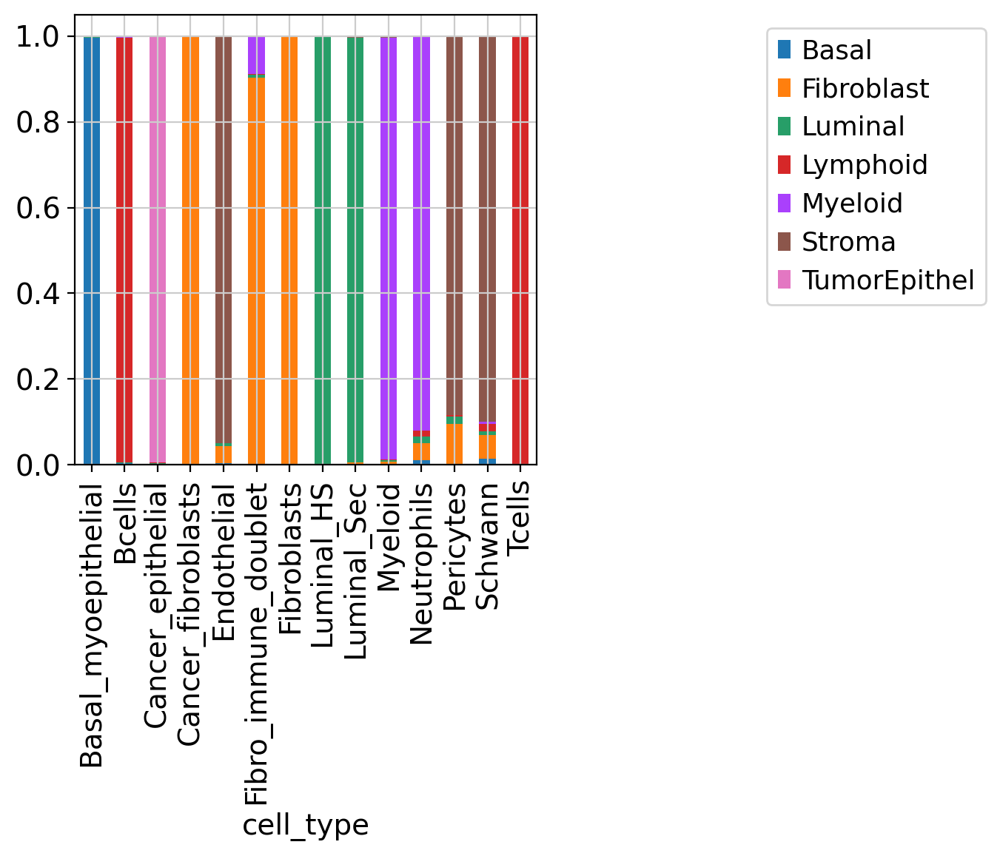

In [106]:
tmp = pd.crosstab(adata.obs['Groups'],adata.obs['cell_type'], 
                  normalize='columns').T.plot(kind='bar', stacked=True)
tmp.legend(title='', bbox_to_anchor=(2, 1),loc='upper right')


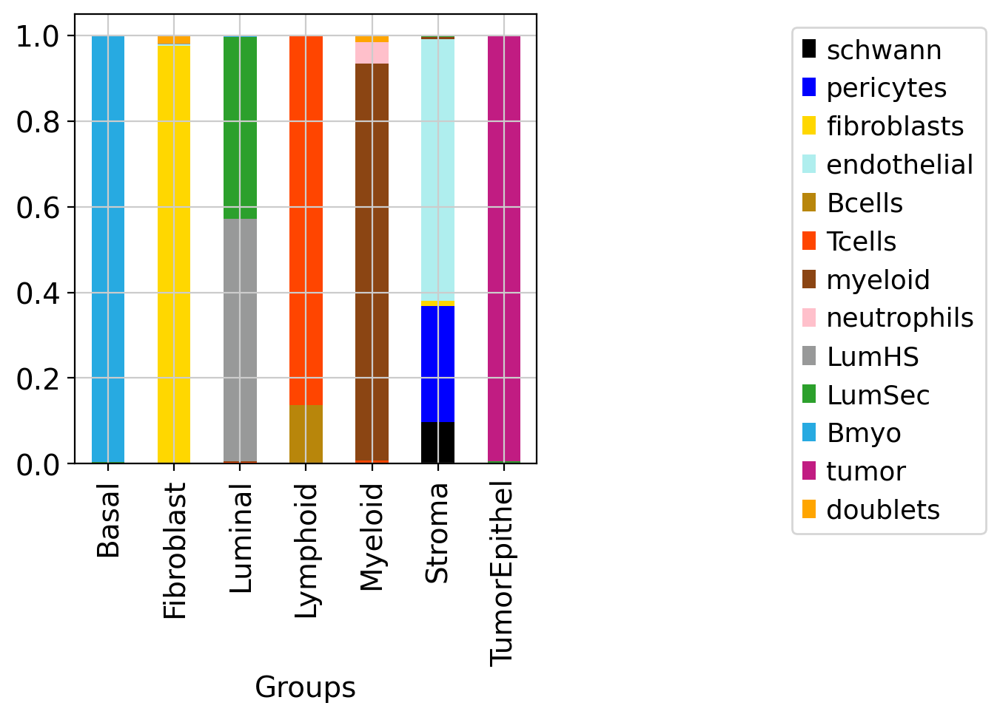

In [23]:
tmp = pd.crosstab(adata.obs['cell_type'],adata.obs['Groups'], 
                  normalize='columns').reindex(["schwann","pericytes","fibroblasts","endothelial",
                              "Bcells","Tcells","myeloid","neutrophils",
                              "LumHS","LumSec","Bmyo",
                              "tumor","doublets"]).T.plot(kind='bar', stacked=True,
                                             color=['black',
                                                                                                                                'blue',
                                                                                                                                'gold',
                                                                                                                                'paleturquoise',
                                                                                                                                'darkgoldenrod',
                                                                                                                                'orangered',
                                                                                                                                'saddlebrown',
                                                                                                                                'pink',
                                                                                                                                '#989999',
                                                                                                                                '#2ca02c',
                                                                                                                                '#27AAE1',
                                                                                                                                '#C11C82',
                                                   'orange'])
tmp.legend(title='', bbox_to_anchor=(2, 1),loc='upper right')
pl.savefig('cell_type_final_vs_orig_group_labels_stackedbar_plot.pdf', bbox_inches='tight')

In [80]:
marker_genes = {
    "Basal_myoep": ["Acta2", "Krt14", "Trp63"],
    "Bcells": ["Cd79a","Cd79a"],
    "Endothelial": ["Pecam1", "Cdh5","Flt1"],
    "Fibroblasts": ["Lum", "Dcn", "Col1a1"],
    "LumHR": ["Prlr", "Foxa1", "Areg"],    
    "LumSec": ["Krt8","Wfdc18","Kit"],
    "Myeloid": ["Ctss","H2-Ab1","Cd74"],
    "Neutrophils": ["Retnlg","Cxcr2","Mmp8"],
    "Pericytes": ["Rgs5","Vim","Sept4"],
    "Tcells": ["Cd3e","Ptprc","Il7r"],
    "Tumor": ["S100a14", "Cdkn2a"],
    "Tumor_HLA": ["Vcam1","Cxcl9","Ccl20"]
}

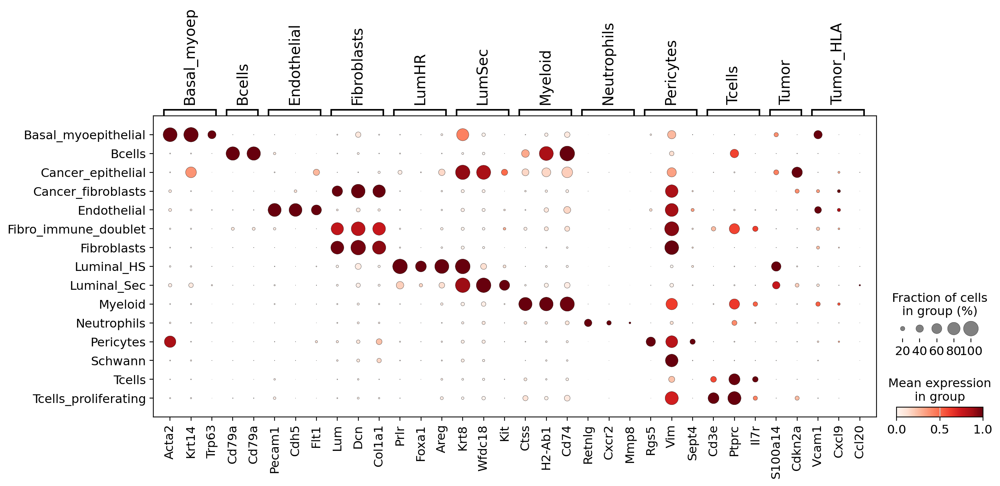

In [81]:
sc.pl.dotplot(adata, marker_genes, groupby="cell_type", standard_scale="var")

In [3]:
full=sc.read_h5ad('all_cells_orig_UMAP.h5ad')

In [8]:
full.obs['barcode'] = barcode['barcode']
full.obs.index = full.obs['barcode']

In [9]:
full.write('all_cells_orig_UMAP.h5ad')

In [151]:
#epi=adata[adata.obs['cell_type'].isin(['Basal_myoepithelial','Luminal_Sec','Luminal_HS','Cancer_epithelial'])]
epi=adata[adata.obs['cell_type'].isin(['Basal_myoepithelial','Luminal_Sec','Cancer_epithelial'])]

In [152]:
sub_barcodes = epi.obs["barcode"]

In [153]:
sub_cells = full[sub_barcodes]

In [154]:
sub_cells

View of AnnData object with n_obs × n_vars = 25980 × 21772
    obs: 'orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'Sample', 'barcode', 'SeqID', 'SampleID', 'Age', 'Condition', 'Batch', 'UmiSums', 'GenesDetected', 'prcntMito', 'residDetectionTrend', 'DbltScore', 'Experiment', 'UMAP1', 'UMAP2', 'Cluster', 'Group', 'MajorGroups', 'Groups', 'CellTypes', 'CellTypesFinal', 'Colors', 'ptime', 'ptimeBin', 'GroupColors', 'UMAP_1', 'UMAP_2'
    obsm: 'X_pca', 'X_umap'

In [155]:
sub_cells.obs["cell_type"] = epi.obs["cell_type"]

/tmp/ipykernel_1320177/182608265.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  sub_cells.obs["cell_type"] = epi.obs["cell_type"]


In [156]:
epi = sub_cells

In [157]:
sc.pp.normalize_total(epi, target_sum=1e4)
sc.pp.log1p(epi)

In [161]:
lumsec = pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/scVI_epithelial/normal_epi/LumSec_sig_degs.csv", index_col = 0)
basal = pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/scVI_epithelial/normal_epi/Basal_sig_degs.csv", index_col = 0)

In [162]:
lumsec = lumsec['names'][:500].to_list()
basal = basal['names'][:500].to_list()

In [165]:
del_lumsec = ['BC006965', 'Ccn1', 'Itprid1', 'Mrtfb', 'Mtss2', 'Ccn5',
       '2700054A10Rik', 'Nectin4', 'Gm35572', 'Prxl2a', 'AC106834.1',
       'Gm20219', 'Gm19303', 'Gm20275', 'Gm45589', 'Tent5a', 'A330023F24Rik',
       'Gm49708', 'Gm50240', 'Snorc', 'Fyb2', 'Meltf', 'Fam241b', 'Garem1',
       'AI463170', 'Catspere2', '4930422I22Rik', '2310002F09Rik', 'Depp1']
del_basal = ['Selenom', 'Cebpd', 'Ecrg4', 'Rflnb', 'Tgfb1i1', 'Mir99ahg', 'Pakap.1',
       'Schip1', 'Gm35333', 'Hdgfl3', 'Cavin2', 'Ccn2', 'Nectin1', 'Cavin1',
       'Cavin3', 'Mir100hg', 'Nectin3', 'Ripor2', 'Mir205hg', 'Ltbp4']

for item in lumsec:
    if item in del_lumsec:
        lumsec.remove(item)
        continue
        
for item in basal:
    if item in del_basal:
        basal.remove(item)
        continue

480

In [167]:
len(lumsec)

471

In [168]:
len(basal)

480

In [166]:
sc.tl.score_genes(epi, lumsec, ctrl_size=len(lumsec),
                  gene_pool=None, n_bins=25, score_name='lumsec', 
                  random_state=0, copy=False, use_raw=None)

sc.tl.score_genes(epi, basal, ctrl_size=len(basal),
                  gene_pool=None, n_bins=25, score_name='basal_neg', 
                  random_state=0, copy=False, use_raw=None)

In [169]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

In [170]:
scaler = MinMaxScaler(feature_range=(-1, 1))
epi.obs[['scaled_lumsec']] = scaler.fit_transform(epi.obs[['lumsec']])

In [171]:
scaler = MinMaxScaler(feature_range=(-1, 1))
epi.obs[['scaled_basal_neg']] = scaler.fit_transform(epi.obs[['basal_neg']])
epi.obs['scaled_basal'] = -epi.obs['scaled_basal_neg']

In [172]:
epi.obs['combined_lumsec_basal'] = epi.obs['scaled_lumsec'] + epi.obs['scaled_basal']

In [173]:
scaler = MinMaxScaler(feature_range=(-1, 1))
epi.obs[['scaled_combined_lumsec_basal']] = scaler.fit_transform(epi.obs[['combined_lumsec_basal']])

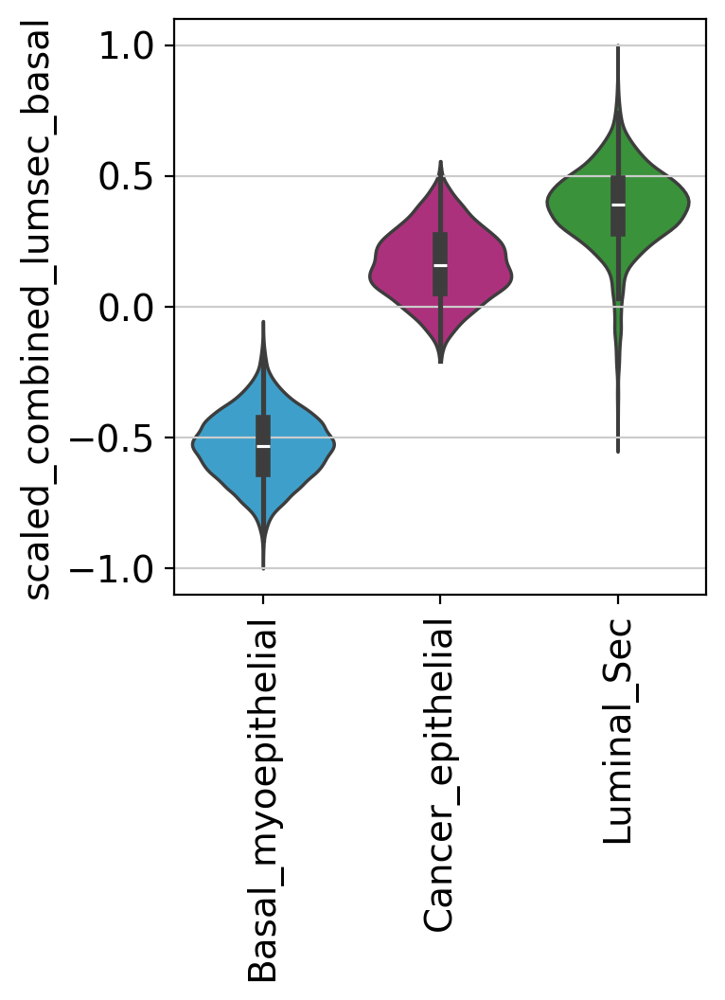

In [175]:
sc.pl.violin(epi, ["scaled_combined_lumsec_basal"], groupby="cell_type", 
             rotation=90, order=['Basal_myoepithelial','Cancer_epithelial','Luminal_Sec'], 
             stripplot=False, palette={'Basal_myoepithelial':'#27AAE1',
              'Cancer_epithelial':'#C11C82',
              'Luminal_Sec':'#2ca02c'},
             inner='box',save='violin_scaled_combined_lumsec_basal.pdf')

In [176]:
epi.obs['scaled_combined_lumsec_basal'].to_csv('blg_scaled_combined_lumsec_basal.csv')

In [10]:
scaled_combined_lumsec_basal=pd.read_csv('blg_scaled_combined_lumsec_basal.csv',index_col=0)

In [12]:
adata.obs['scaled_combined_lumsec_basal']=scaled_combined_lumsec_basal['scaled_combined_lumsec_basal']

In [13]:
adata

AnnData object with n_obs × n_vars = 128807 × 1050
    obs: 'orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'Sample', 'barcode', 'SeqID', 'SampleID', 'Age', 'Condition', 'Batch', 'UmiSums', 'GenesDetected', 'prcntMito', 'residDetectionTrend', 'DbltScore', 'Experiment', 'UMAP1', 'UMAP2', 'Cluster', 'Group', 'MajorGroups', 'Groups', 'CellTypes', 'CellTypesFinal', 'Colors', 'ptime', 'ptimeBin', 'GroupColors', 'UMAP_1', 'UMAP_2', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'leiden', 'cell_type', 'subtype', 'p.value', 'correlation', 'cnv', 'ploidy', 'scaled_combined_lumsec_basal'
    var: 'n_cells', 'mc_Fano', 'FDR_adj_pvalue', 'p_value', 'highly_variable', 'mt', 'ribo', 'n_cells_by_counts',

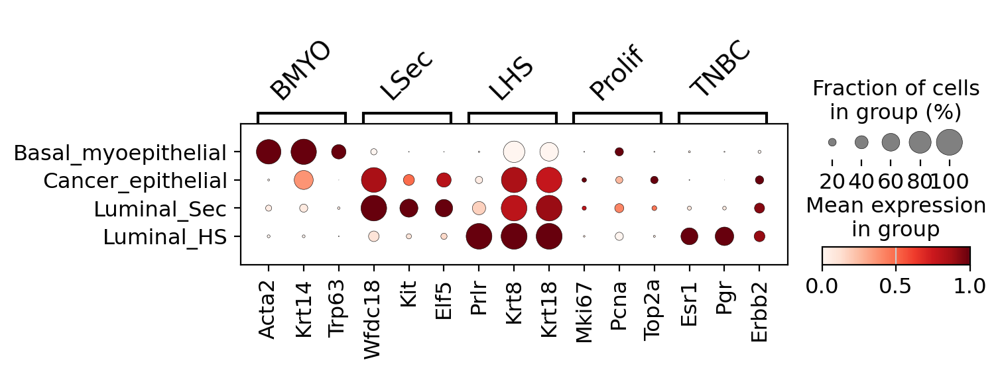

In [139]:
marker_genes = {
    "BMYO": ["Acta2","Krt14","Trp63"],
    "LSec": ["Wfdc18","Kit","Elf5"],
    "LHS": ["Prlr","Krt8","Krt18"],
    "Prolif": ["Mki67","Pcna","Top2a"],
    "TNBC": ["Esr1","Pgr","Erbb2"]
}

sc.tl.dendrogram(epi, groupby = "cell_type")

sc.pl.dotplot(epi, marker_genes, groupby="cell_type",
              var_group_rotation=45,categories_order=['Basal_myoepithelial','Cancer_epithelial','Luminal_Sec','Luminal_HS'],
              standard_scale="var",save='tnbc_epi_celltypes.pdf')

In [14]:
res1 = pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/scVI_epithelial/TNBC_subtyper/result_singlecell.csv")

res1 = res1[res1['Unnamed: 0'].str.startswith('wk')]
res1['Unnamed: 0'] = res1['Unnamed: 0'].str.replace('wk_', '')
res1['Unnamed: 0'] = res1['Unnamed: 0'].str.replace('.', '-')

res1.set_index("Unnamed: 0", inplace=True)


res2 = pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/scVI_epithelial/TNBC_subtyper/result_mouse_single_cell_lumhr_noESR.csv")

res2 = res2[res2['Unnamed: 0'].str.startswith('wk')]
res2['Unnamed: 0'] = res2['Unnamed: 0'].str.replace('wk_', '')
res2['Unnamed: 0'] = res2['Unnamed: 0'].str.replace('.', '-')

res2.set_index("Unnamed: 0", inplace=True)


res3 = pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/scVI_epithelial/TNBC_subtyper/result_mouse_single_cell_normal_epithelial_without_lumhr.csv")

res3 = res3[res3['Unnamed: 0'].str.startswith('wk')]
res3['Unnamed: 0'] = res3['Unnamed: 0'].str.replace('wk_', '')
res3['Unnamed: 0'] = res3['Unnamed: 0'].str.replace('.', '-')

res3.set_index("Unnamed: 0", inplace=True)

In [15]:
res = pd.concat([res1, res2, res3], axis=0)

In [18]:
adata.obs['sc_TNBC_subtype'] = res['subtype']
adata.obs['sc_TNBC_subtype_correlation'] = res['correlation']
adata.obs['sc_TNBC_subtype_p_value'] = res['p.value']

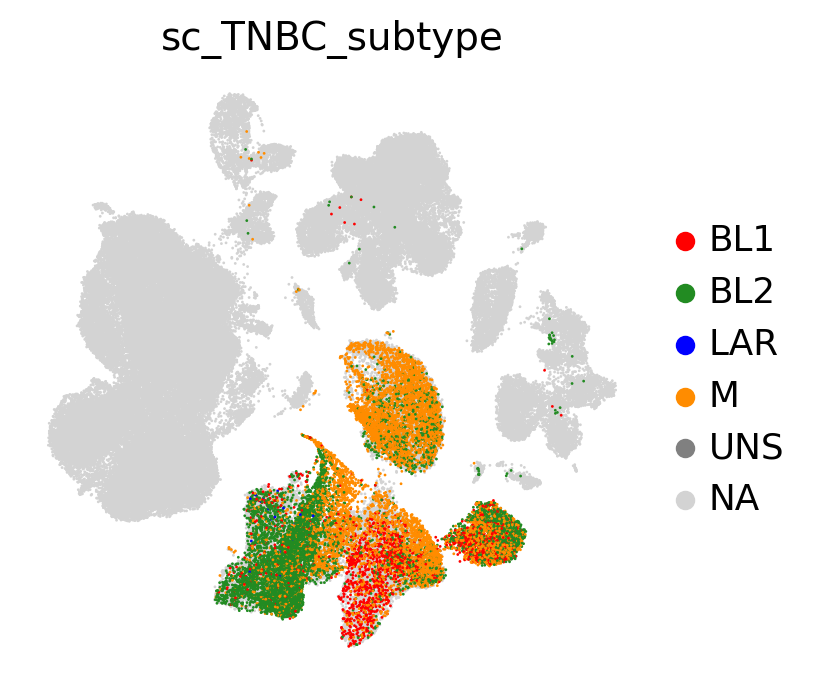

In [20]:
sc.pl.umap(adata, color=["sc_TNBC_subtype"], palette = {'BL1':'red',
                                                'BL2':'forestgreen',
                                                'LAR':'blue',
                                               'M':'darkorange',
                                               'UNS':'grey'},
          s = 4)

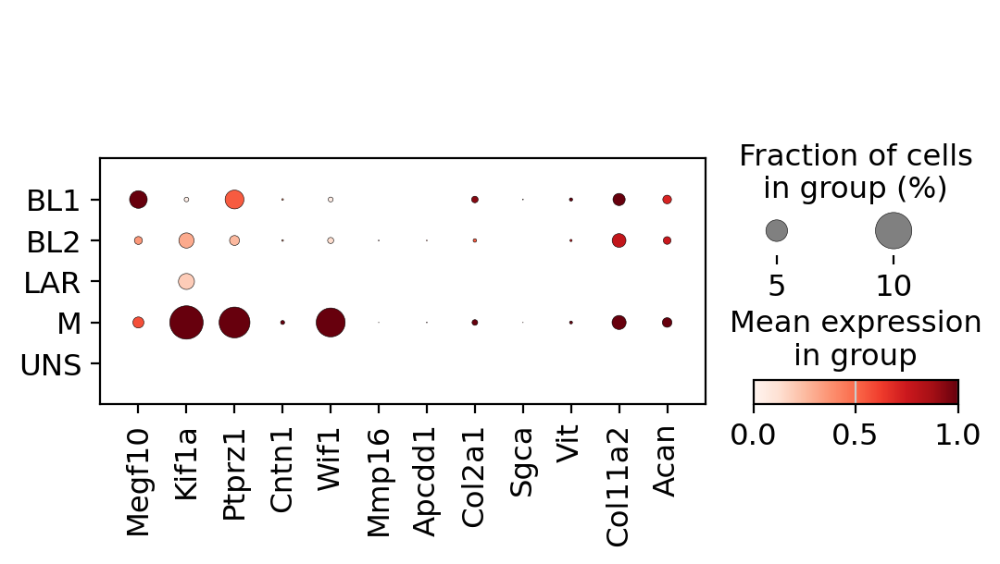

In [183]:
sc.pl.dotplot(adata, ["Megf10",
                   "Kif1a",
                   'Ptprz1',
 'Cntn1',
 'Wif1',
 'Mmp16',
 'Apcdd1',
 'Col2a1',
 'Sgca',
 'Vit',
 'Col11a2',
                  'Acan',], groupby="subtype",
              standard_scale="var")
#heatmap of pseudo-singlecell

# Figure 2

In [4]:
adata = sc.read_h5ad('all_cells_bigsur_merged.h5ad')

In [5]:
sub = adata[~adata.obs['Group'].isin(['WKBR_MG'])]
sub = sub[~sub.obs['SampleID'].isin(['CBLT','CBLA13'])]
sub = sub[sub.obs['cell_type'].isin(['Bmyo', 'LumSec', 'tumor'])]

In [6]:
sub.obs['Group'].value_counts()

Group
WKBR_Tumor    3121
Control       1630
Name: count, dtype: int64

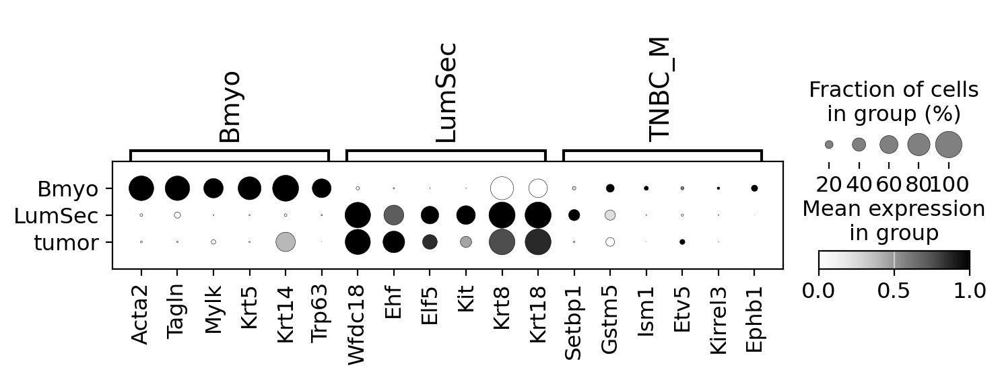

In [10]:
marker_genes = {
    "Bmyo": ["Acta2","Tagln","Mylk","Krt5","Krt14","Trp63"],
    "LumSec": ["Wfdc18","Ehf","Elf5","Kit","Krt8","Krt18"],
    "TNBC_M":["Setbp1","Gstm5","Ism1","Etv5","Kirrel3","Ephb1"]}


sc.pl.dotplot(sub, marker_genes, groupby="cell_type",standard_scale="var",swap_axes=False,cmap='Greys',save='_blg_canonical_mesenchymal.pdf')
 #            categories_order=['Bmyo', 'LumSec', 'TNBC_M', 'TNBC_other'])#,save='_wap_canonical_mesenchymal.pdf')

<h2 id="Figure-3">Figure 3</h2>

In [5]:
adata = sc.read_h5ad('all_cells_bigsur_merged.h5ad')

In [6]:
adata

AnnData object with n_obs × n_vars = 128807 × 1050
    obs: 'orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'Sample', 'barcode', 'SeqID', 'SampleID', 'Age', 'Condition', 'Batch', 'UmiSums', 'GenesDetected', 'prcntMito', 'residDetectionTrend', 'DbltScore', 'Experiment', 'UMAP1', 'UMAP2', 'Cluster', 'Group', 'MajorGroups', 'Groups', 'CellTypes', 'CellTypesFinal', 'Colors', 'ptime', 'ptimeBin', 'GroupColors', 'UMAP_1', 'UMAP_2', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'leiden', 'cell_type', 'subtype', 'p.value', 'correlation', 'cnv'
    var: 'n_cells', 'mc_Fano', 'FDR_adj_pvalue', 'p_value', 'highly_variable', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_

In [14]:
adata.obs['Group'].value_counts()

Group
WKBR_MG       83581
Control       38487
WKBR_Tumor     6739
Name: count, dtype: int64

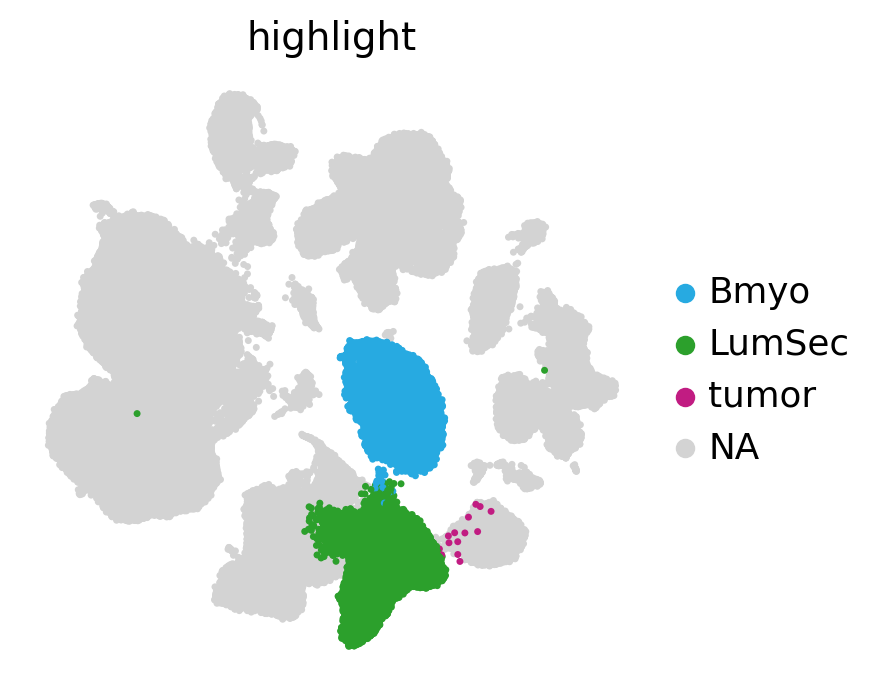

In [15]:
highlight = adata[adata.obs['Group'].isin(['WKBR_MG','Control'])]
highlight = highlight[highlight.obs['cell_type'].isin(['Bmyo','LumSec','tumor'])]

adata.obs['highlight'] = highlight.obs['cell_type']

sc.pl.umap(adata, color='highlight', size=25,
          palette = {'Bmyo':'#27AAE1','LumSec':'#2ca02c','tumor':'#C11C82'})

<h1 id="Figure-1">Towards Figure 1</h1>

In [35]:
overlap_list=pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/merged_scanpy/tcga_nathanson_overlap_genes_as_mouse.csv", index_col=1)

In [36]:
overlap_list=overlap_list.index.to_list()

In [37]:
len(overlap_list)

111

In [2]:
adata = sc.read_h5ad('all_cells_bigsur_merged.h5ad')

In [3]:
sub = adata[~adata.obs['Group'].isin(['WKBR_MG'])]
sub = sub[~sub.obs['SampleID'].isin(['CBLT','CBLA13'])]
sub = sub[sub.obs['cell_type'].isin(['Bmyo', 'LumSec', 'tumor'])]

In [4]:
sub=sub.raw.to_adata()

In [5]:
sub.obs['SampleID'].value_counts()

SampleID
WKBR61.4dTM    3092
CTRL_2          864
CTRL_1          453
CTRL_3          313
WKBR75.4bTM      29
Name: count, dtype: int64

In [6]:
sc.pp.normalize_total(sub, target_sum=1e4)
sc.pp.log1p(sub)

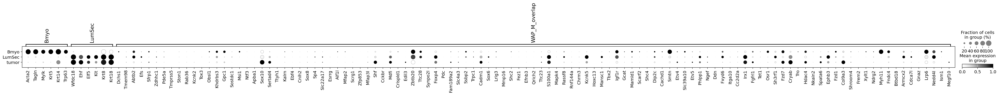

In [82]:
marker_genes = {
    "Bmyo": ["Acta2","Tagln","Mylk","Krt5","Krt14","Trp63"],
    "LumSec": ["Wfdc18","Ehf","Elf5","Kit","Krt8","Krt18"],
    "WAP_M_overlap":overlap_list}


sc.pl.dotplot(sub, marker_genes, groupby="cell_type",standard_scale="var",swap_axes=False,cmap='Greys',
             categories_order=['Bmyo', 'LumSec', 'tumor'])

In [43]:
sc.tl.score_genes(adata, overlap_list,
                  gene_pool=None, n_bins=25, score_name='tcga_nathanson_M_overlap', 
                  random_state=0, copy=False, use_raw=None)

/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:907: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


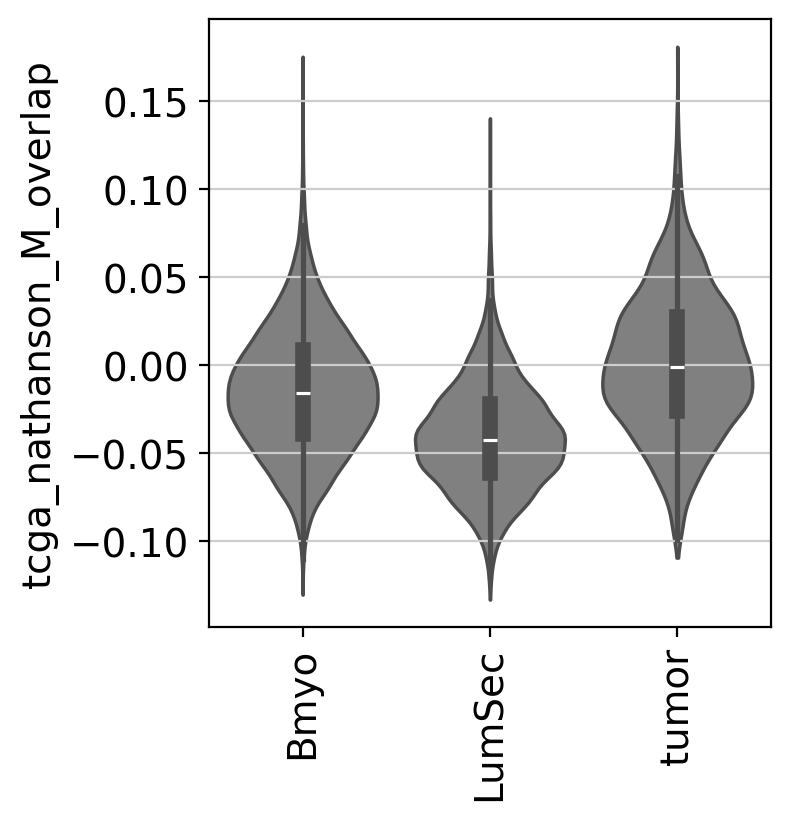

In [44]:
sc.pl.violin(adata, ["tcga_nathanson_M_overlap"], groupby="cell_type", 
             rotation=90, order=['Bmyo', 'LumSec', 'tumor'], 
             stripplot=False, palette=['grey','grey','grey'],
             inner='box')

In [8]:
tcga=pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/TCGA/tcga_mesenchymal_genes_as_mouse.csv")
tcga=tcga['genes_upper'].to_list()

       'C12orf73', '4930503l19rik', 'Znf660', 'Cdh12',
       ...
       'C20orf112', 'Accn2', 'Maged4b', 'C12orf53', 'Gdf1', 'Geft',
       'C20orf117', 'C1orf133', '1700030k09rik', 'D630045j12rik'],
      dtype='object', length=224)


/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:907: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


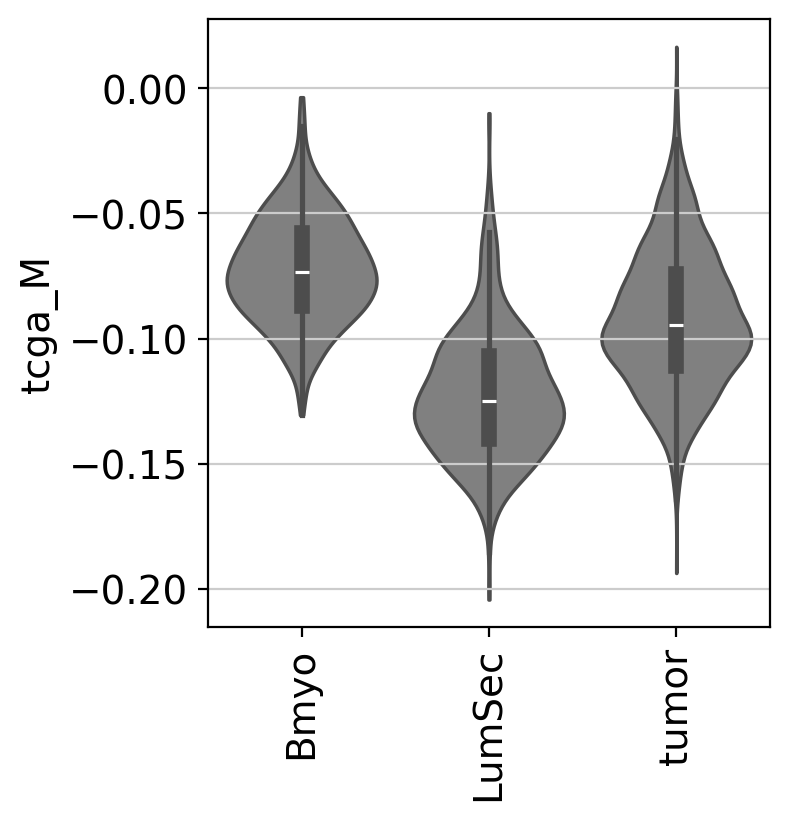

In [85]:
sc.tl.score_genes(sub, tcga,
                  gene_pool=None, n_bins=25, score_name='tcga_M', 
                  random_state=0, copy=False, use_raw=None)

sc.pl.violin(sub, ["tcga_M"], groupby="cell_type", 
             rotation=90, order=['Bmyo', 'LumSec', 'tumor'], 
             stripplot=False, palette=['grey','grey','grey'],
             inner='box')

In [48]:
nathanson=pd.read_csv("/share/crsp/lab/dalawson/share/BRCA_Nathanson_bulk/nathanson_mesenchymal_genes_as_mouse.csv")
nathanson=nathanson['genes_upper'].to_list()

       'Rp11-329a14.11', 'Pgam1p7', 'Krt40', 'Ac097523.3',
       ...
       'Mapre1p1', 'Enam', 'Ccl71', 'Serpinb91', 'Siglecl2', 'Cxcr31',
       'Trim171', 'Ccr11', 'Cxcr2p1', 'Ubash3a1'],
      dtype='object', length=362)


/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:907: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


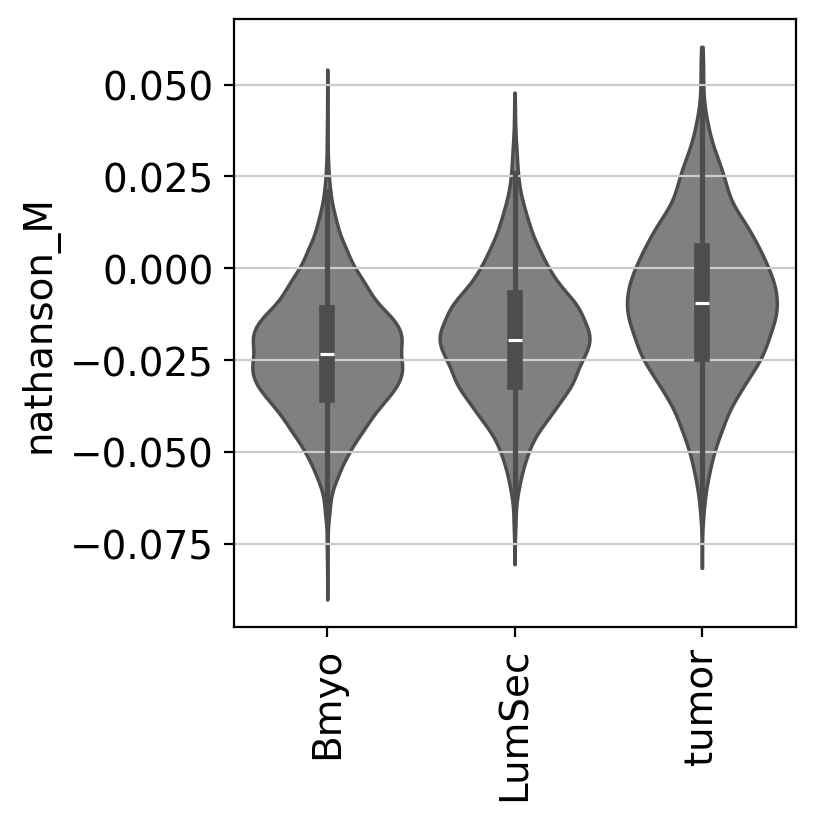

In [73]:
sc.tl.score_genes(adata, nathanson,
                  gene_pool=None, n_bins=25, score_name='nathanson_M', 
                  random_state=0, copy=False, use_raw=None)

sc.pl.violin(adata, ["nathanson_M"], groupby="cell_type", 
             rotation=90, order=['Bmyo', 'LumSec', 'tumor'], 
             stripplot=False, palette=['grey','grey','grey'],
             inner='box')

In [7]:
tcga=pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/scVI_epithelial/hbca/tcga_mesenchymal_genes_as_human_and_mouse_nonoverlap_removed.csv")

In [8]:
tcga=tcga['genes_upper'].to_list()

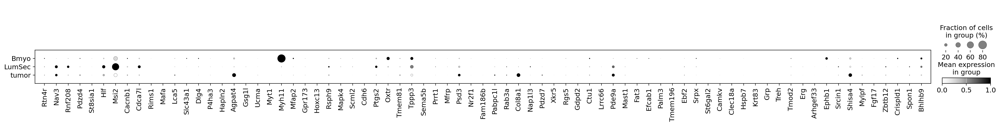

In [10]:
tcga_25=tcga[50:125]

marker_genes = tcga_25

sc.pl.dotplot(sub, marker_genes, groupby="cell_type",standard_scale="var",swap_axes=False,cmap='Greys')

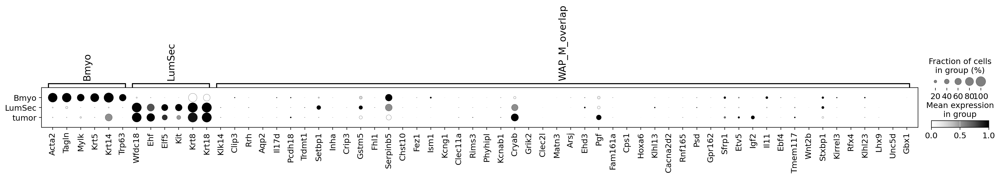

In [9]:
tcga_25=tcga[0:50]

marker_genes = {
    "Bmyo": ["Acta2","Tagln","Mylk","Krt5","Krt14","Trp63"],
    "LumSec": ["Wfdc18","Ehf","Elf5","Kit","Krt8","Krt18"],
    "WAP_M_overlap":tcga_25}

sc.pl.dotplot(sub, marker_genes, groupby="cell_type",standard_scale="var",swap_axes=False,cmap='Greys')

In [ ]:
marker_genes = ["","","","","",""]


sc.pl.dotplot(sub, marker_genes, groupby="cell_type",standard_scale="var",swap_axes=False,cmap='Greys',
             categories_order=['Bmyo', 'LumSec', 'tumor'])

In [5]:
#TCGA
overlap=pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/TCGA/tcga_mesenchymal_wap_overlap_genes_as_mouse.csv")
genes=overlap['names'].to_list()

In [6]:
genes.remove('D630045j12rik')
genes.remove('Myef2l')
genes.remove('H19')

In [15]:
adata=adata.raw.to_adata()

In [16]:
sub = adata[adata.obs['cell_type'].isin(['Bmyo', 'LumSec', 'tumor'])]

In [17]:
sc.pp.normalize_total(sub, target_sum=1e4)
sc.pp.log1p(sub)

/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:206: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


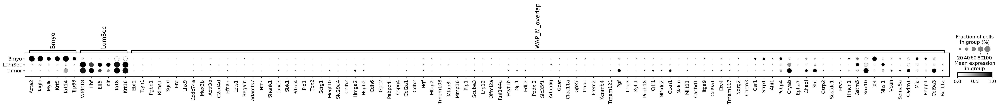

In [11]:
marker_genes = {
    "Bmyo": ["Acta2","Tagln","Mylk","Krt5","Krt14","Trp63"],
    "LumSec": ["Wfdc18","Ehf","Elf5","Kit","Krt8","Krt18"],
    "WAP_M_overlap":genes}


sc.pl.dotplot(sub, marker_genes, groupby="cell_type",standard_scale="var",swap_axes=False,cmap='Greys',
             categories_order=['Bmyo', 'LumSec', 'tumor'])

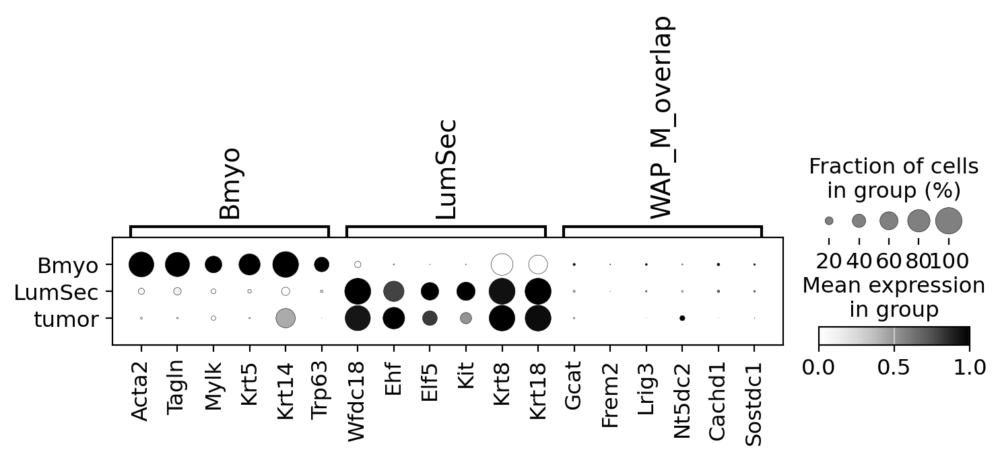

In [13]:
marker_genes = {
    "Bmyo": ["Acta2","Tagln","Mylk","Krt5","Krt14","Trp63"],
    "LumSec": ["Wfdc18","Ehf","Elf5","Kit","Krt8","Krt18"],
    "WAP_M_overlap":["Gcat","Frem2","Lrig3","Nt5dc2","Cachd1","Sostdc1"]}


sc.pl.dotplot(sub, marker_genes, groupby="cell_type",standard_scale="var",swap_axes=False,cmap='Greys',
             categories_order=['Bmyo', 'LumSec', 'tumor'])

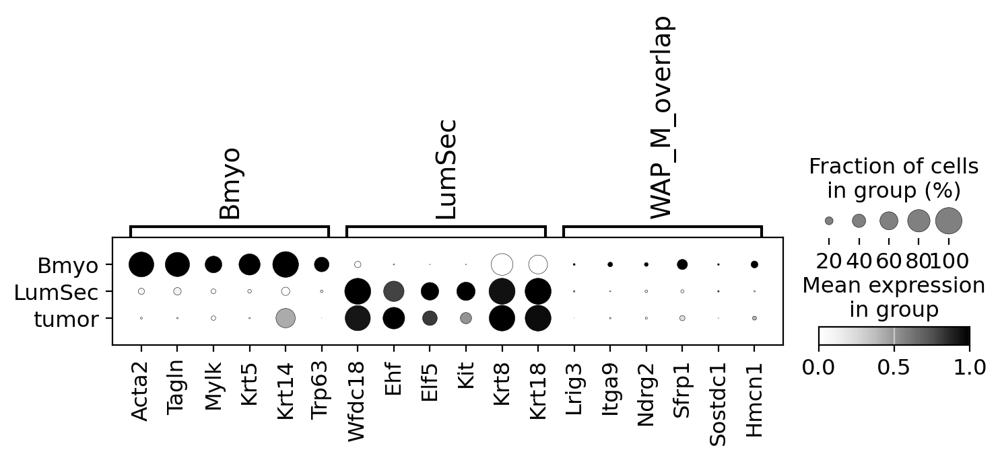

In [18]:
marker_genes = {
    "Bmyo": ["Acta2","Tagln","Mylk","Krt5","Krt14","Trp63"],
    "LumSec": ["Wfdc18","Ehf","Elf5","Kit","Krt8","Krt18"],
    "WAP_M_overlap":["Lrig3","Itga9","Ndrg2","Sfrp1","Sostdc1","Hmcn1"]}


sc.pl.dotplot(sub, marker_genes, groupby="cell_type",standard_scale="var",swap_axes=False,cmap='Greys',
             categories_order=['Bmyo', 'LumSec', 'tumor'])

In [19]:
overlap=pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/TCGA/tcga_nathanson_mesenchymal_wap_overlap_genes_as_mouse.csv", index_col=1)
genes=overlap.index.to_list()

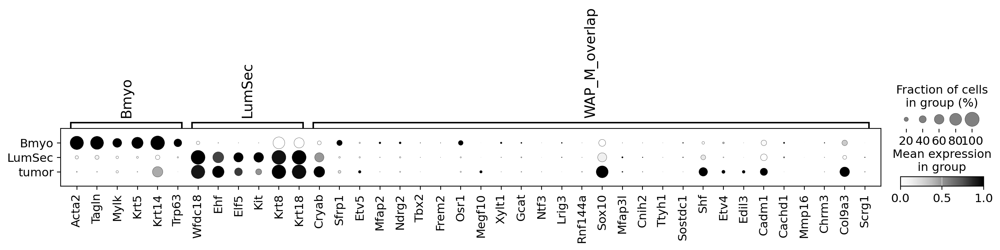

In [20]:
marker_genes = {
    "Bmyo": ["Acta2","Tagln","Mylk","Krt5","Krt14","Trp63"],
    "LumSec": ["Wfdc18","Ehf","Elf5","Kit","Krt8","Krt18"],
    "WAP_M_overlap":genes}


sc.pl.dotplot(sub, marker_genes, groupby="cell_type",standard_scale="var",swap_axes=False,cmap='Greys',
             categories_order=['Bmyo', 'LumSec', 'tumor'])

# initial try

In [10]:
overlap=pd.read_csv("/share/crsp/lab/dalawson/share/BRCA_Nathanson_bulk/mesenchymal_wap_overlap_genes.csv")
overlap['gene_mouse'] = overlap['gene'].str.capitalize()
genes=overlap['gene_mouse'].to_list()

In [11]:
genes.remove('Kiaa1549')
genes.remove('Siah1')
genes.remove('Znf25')

In [12]:
adata=adata.raw.to_adata()

In [14]:
sub = adata[adata.obs['cell_type'].isin(['Bmyo', 'LumSec', 'tumor'])]

In [15]:
sc.pp.normalize_total(sub, target_sum=1e4)
sc.pp.log1p(sub)

/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:206: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


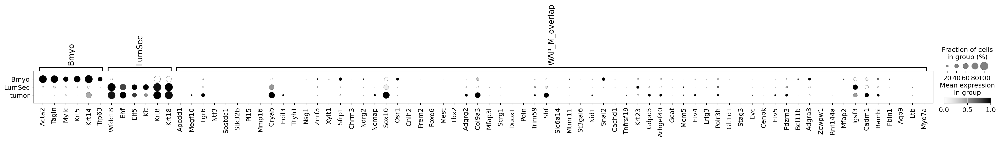

In [17]:
marker_genes = {
    "Bmyo": ["Acta2","Tagln","Mylk","Krt5","Krt14","Trp63"],
    "LumSec": ["Wfdc18","Ehf","Elf5","Kit","Krt8","Krt18"],
    "WAP_M_overlap":genes}


sc.pl.dotplot(sub, marker_genes, groupby="cell_type",standard_scale="var",swap_axes=False,cmap='Greys',
             categories_order=['Bmyo', 'LumSec', 'tumor'])

# Get DEGs for signature equivalent to BLG

In [ ]:
adata = sc.read_h5ad('all_cells_bigsur_merged.h5ad')

In [ ]:
adata.obs.to_csv('metadata_all_cells_bigsur_merged.csv')

In [ ]:
full=sc.read_h5ad('all_cells_orig_UMAP.h5ad')

In [ ]:
sub_barcodes = adata.obs["barcode"]
sub = full[sub_barcodes]

In [ ]:
sub.obs['cell_type']=adata.obs['cell_type']

In [ ]:
sub

AnnData object with n_obs × n_vars = 128807 × 21772
    obs: 'orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'Sample', 'barcode', 'SeqID', 'SampleID', 'Age', 'Condition', 'Batch', 'UmiSums', 'GenesDetected', 'prcntMito', 'residDetectionTrend', 'DbltScore', 'Experiment', 'UMAP1', 'UMAP2', 'Cluster', 'Group', 'MajorGroups', 'Groups', 'CellTypes', 'CellTypesFinal', 'Colors', 'ptime', 'ptimeBin', 'GroupColors', 'UMAP_1', 'UMAP_2', 'cell_type'
    uns: 'log1p'
    obsm: 'X_pca', 'X_umap'

In [ ]:
sc.pp.normalize_total(sub, target_sum=1e4)
sc.pp.log1p(sub)

/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:206: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [ ]:
sub.obs['cell_type'].value_counts()

cell_type
Fibroblasts             54482
Tcells                  19836
Basal_myoepithelial     14042
Luminal_HS              11734
Luminal_Sec              8870
Myeloid                  6414
Bcells                   3166
Cancer_epithelial        3068
Endothelial              2983
Pericytes                1426
Fibro_immune_doublet     1200
Cancer_fibroblasts        723
Schwann                   497
Neutrophils               366
Name: count, dtype: int64

In [ ]:
normal = sub[sub.obs['Group'].isin(["Control"])]
normal = normal[normal.obs['cell_type'].isin(["Luminal_Sec","Luminal_HS","Basal_myoepithelial"])]

In [ ]:
df = normal.obs[['cell_type']].copy()

clusters_key = 'cell_type'

sample_size = 1000  # Define your desired sample size

unique_clusters = normal.obs['cell_type'].unique()

# Prepare a dictionary to store the sampled cells
sampled_cells = {cluster: [] for cluster in unique_clusters}

# Sample cells from each cluster
for cluster in unique_clusters:
    sample_size = 1000
    cluster_cells = df[df[clusters_key] == cluster].index
    if len(cluster_cells) < sample_size:
        print(f"Warning: Cluster '{cluster}' has fewer cells than the sample size. Sampling all cells.")
        sample_size = len(cluster_cells)  # Adjust sample size if not enough cells
    sampled_cells[cluster] = np.random.choice(cluster_cells, size=sample_size, replace=False)

In [ ]:
sampled_cells_df = pd.DataFrame([(cluster, cell) for cluster, cells in sampled_cells.items() for cell in cells], columns=[clusters_key, 'cell_id'])
sampled_adata = sub[sub.obs.index.isin(sampled_cells_df['cell_id']), :]

In [ ]:
sampled_adata.obs['SampleID'].value_counts()

SampleID
CTRL_2    964
CBLT      765
CTRL_1    529
CBLA13    524
CTRL_3    218
Name: count, dtype: int64

In [ ]:
barcodes_to_keep = sampled_adata.obs['barcode'].to_list()

In [ ]:
tum = sub[sub.obs['Group'].isin(["WKBR_Tumor"])]
tum = tum[tum.obs['cell_type'].isin(["Cancer_epithelial"])]

In [ ]:
tum

View of AnnData object with n_obs × n_vars = 3052 × 21772
    obs: 'orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'Sample', 'barcode', 'SeqID', 'SampleID', 'Age', 'Condition', 'Batch', 'UmiSums', 'GenesDetected', 'prcntMito', 'residDetectionTrend', 'DbltScore', 'Experiment', 'UMAP1', 'UMAP2', 'Cluster', 'Group', 'MajorGroups', 'Groups', 'CellTypes', 'CellTypesFinal', 'Colors', 'ptime', 'ptimeBin', 'GroupColors', 'UMAP_1', 'UMAP_2', 'cell_type'
    uns: 'log1p'
    obsm: 'X_pca', 'X_umap'

In [ ]:
df = tum.obs[['cell_type']].copy()

clusters_key = 'cell_type'

sample_size = 5000  # Define your desired sample size

unique_clusters = tum.obs['cell_type'].unique()

# Prepare a dictionary to store the sampled cells
sampled_cells = {cluster: [] for cluster in unique_clusters}

# Sample cells from each cluster
for cluster in unique_clusters:
    sample_size = 5000
    cluster_cells = df[df[clusters_key] == cluster].index
    if len(cluster_cells) < sample_size:
        print(f"Warning: Cluster '{cluster}' has fewer cells than the sample size. Sampling all cells.")
        sample_size = len(cluster_cells)  # Adjust sample size if not enough cells
    sampled_cells[cluster] = np.random.choice(cluster_cells, size=sample_size, replace=False)

In [40]:
sampled_cells_df = pd.DataFrame([(cluster, cell) for cluster, cells in sampled_cells.items() for cell in cells], columns=[clusters_key, 'cell_id'])
sampled_adata = sub[sub.obs.index.isin(sampled_cells_df['cell_id']), :]

In [41]:
sampled_adata.obs['SampleID'].value_counts()

SampleID
WKBR61.4dTM    3052
Name: count, dtype: int64

In [42]:
sampled_adata

View of AnnData object with n_obs × n_vars = 3052 × 21772
    obs: 'orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'Sample', 'barcode', 'SeqID', 'SampleID', 'Age', 'Condition', 'Batch', 'UmiSums', 'GenesDetected', 'prcntMito', 'residDetectionTrend', 'DbltScore', 'Experiment', 'UMAP1', 'UMAP2', 'Cluster', 'Group', 'MajorGroups', 'Groups', 'CellTypes', 'CellTypesFinal', 'Colors', 'ptime', 'ptimeBin', 'GroupColors', 'UMAP_1', 'UMAP_2', 'cell_type'
    uns: 'log1p'
    obsm: 'X_pca', 'X_umap'

In [43]:
tumor_barcodes_to_keep = sampled_adata.obs['barcode'].to_list()

In [44]:
merged_list = tumor_barcodes_to_keep + barcodes_to_keep
subset_test = sub[sub.obs['barcode'].isin(merged_list)]

In [45]:
subset_test

View of AnnData object with n_obs × n_vars = 6052 × 21772
    obs: 'orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'Sample', 'barcode', 'SeqID', 'SampleID', 'Age', 'Condition', 'Batch', 'UmiSums', 'GenesDetected', 'prcntMito', 'residDetectionTrend', 'DbltScore', 'Experiment', 'UMAP1', 'UMAP2', 'Cluster', 'Group', 'MajorGroups', 'Groups', 'CellTypes', 'CellTypesFinal', 'Colors', 'ptime', 'ptimeBin', 'GroupColors', 'UMAP_1', 'UMAP_2', 'cell_type'
    uns: 'log1p'
    obsm: 'X_pca', 'X_umap'

In [46]:
pd.crosstab(subset_test.obs['SampleID'],subset_test.obs['cell_type'])

cell_type,Basal_myoepithelial,Cancer_epithelial,Luminal_HS,Luminal_Sec
SampleID,,,,
CBLA13,339,0,23,162
CBLT,445,0,70,250
CTRL_1,56,0,315,158
CTRL_2,112,0,523,329
CTRL_3,48,0,69,101
WKBR61.4dTM,0,3052,0,0


In [48]:
sc.pp.normalize_total(subset_test, target_sum=1e4)
sc.pp.log1p(subset_test)

/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:206: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [49]:
sc.tl.rank_genes_groups(subset_test, groupby="cell_type", method="wilcoxon")
sc.tl.dendrogram(subset_test, groupby='cell_type')

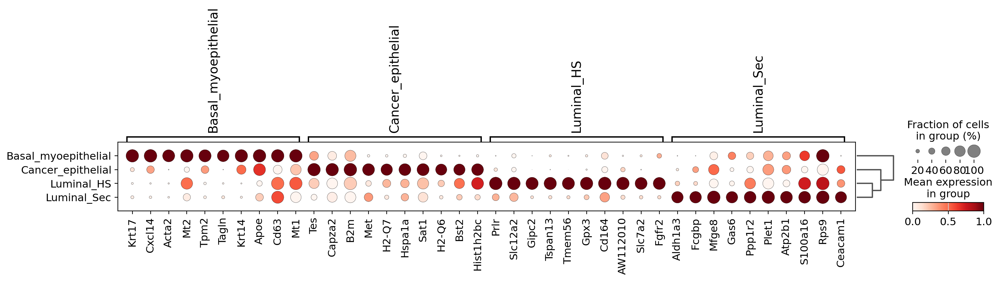

In [50]:
sc.pl.rank_genes_groups_dotplot(
    subset_test, groupby="cell_type", standard_scale="var", n_genes=10
)

In [52]:
df_Tumor = sc.get.rank_genes_groups_df(subset_test, 'Cancer_epithelial')

In [53]:
df_Tumor = df_Tumor[df_Tumor['pvals_adj'] < 0.05]
df_Tumor = df_Tumor[df_Tumor['logfoldchanges'] > 1.5]

In [55]:
df_Tumor.to_csv("blg_sig_degs_subsampled_bigsur_celltypes_tumor_vs_all_else_normal_wilcox.csv")

In [ ]:
## all cells, no subsampling

In [77]:
adata.obs["cell_type_hla"] = adata.obs["leiden"].map(
    {
        "0": "Basal_myoep",
        "1": "Tumor",
        "2": "Fibroblasts",
        "3": "Luminal_HR",
        "4": "Myeloid",
        "5": "Luminal_Sec",
        "6": "Tumor",
        "7": "Pericytes",
        "8": "Neutrophils",
        "9": "Tcells",
        "10": "Myeloid",
        "11": "Endothelial",
        "12": "Tumor",
        "13": "Fibroblasts",
        "14": "Bcells",
        "15": "Tumor" 
    }
)

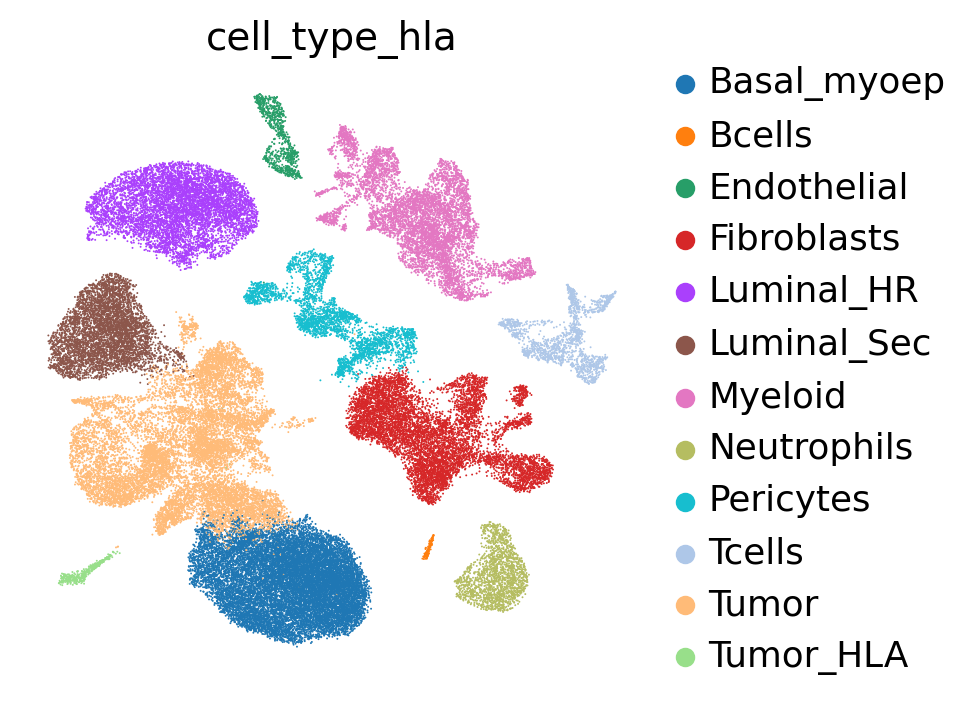

In [78]:
sc.pl.umap(
    adata,
    color=["cell_type_hla"],
    wspace=0.5,
    ncols=3)

In [39]:
adata = no_mut

In [40]:
sub_barcodes = adata.obs["barcode"]
sub_cells = full[sub_barcodes]

In [41]:
sub_cells.obs['cell_type'] = adata.obs['cell_type']

/tmp/ipykernel_110346/377445879.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  sub_cells.obs['cell_type'] = adata.obs['cell_type']


In [42]:
adata = sub_cells

In [43]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [45]:
sc.tl.rank_genes_groups(adata, groupby="cell_type", method="wilcoxon")
sc.tl.dendrogram(adata, groupby='cell_type')

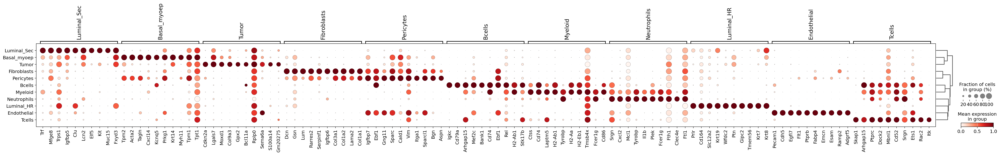

In [46]:
sc.pl.rank_genes_groups_dotplot(
    adata, groupby="cell_type", standard_scale="var", n_genes=10
)

In [47]:
df_Tumor = sc.get.rank_genes_groups_df(adata, 'Tumor')

In [48]:
df_Tumor = df_Tumor[df_Tumor['pvals_adj'] < 0.05]
df_Tumor = df_Tumor[df_Tumor['logfoldchanges'] > 1.5]